## 1. 数据读取 + Dataset 构建代码


In [3]:
# 本代码块：导入依赖并设置全局配置
import os
import copy
import time
import random
import numpy as np
import pandas as pd
from PIL import Image, ImageFilter

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models

from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score
import matplotlib.pyplot as plt


In [4]:
# 本代码块：设置随机种子与基础路径
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

set_seed(42)

data_dir = "./CXR8"
csv_path = os.path.join(data_dir, "Data_Entry_2017_v2020.csv")
img_dir = os.path.join(data_dir, "images", "images")
train_list = os.path.join(data_dir, "train_val_list.txt")
test_list = os.path.join(data_dir, "test_list.txt")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)


device: cpu


In [5]:
# 本代码块：读取标签表并构建类别映射
df = pd.read_csv(csv_path)

all_labels = sorted({
    label
    for label_string in df["Finding Labels"]
    for label in label_string.split("|")
})
label_map = {label: idx for idx, label in enumerate(all_labels)}

print("总样本数:", len(df))
print("类别数:", len(all_labels))
print(all_labels)

df.head()


总样本数: 112120
类别数: 15
['Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Effusion', 'Emphysema', 'Fibrosis', 'Hernia', 'Infiltration', 'Mass', 'No Finding', 'Nodule', 'Pleural_Thickening', 'Pneumonia', 'Pneumothorax']


,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Sex,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y]
0,00000001_000.png,Cardiomegaly,0,1,57,M,PA,2682,2749,0.143,0.143
1,00000001_001.png,Cardiomegaly|Emphysema,1,1,58,M,PA,2894,2729,0.143,0.143
2,00000001_002.png,Cardiomegaly|Effusion,2,1,58,M,PA,2500,2048,0.168,0.168
3,00000002_000.png,No Finding,0,2,80,M,PA,2500,2048,0.171,0.171
4,00000003_001.png,Hernia,0,3,74,F,PA,2500,2048,0.168,0.168


In [6]:
# 本代码块：按官方列表划分 full / small / medium 三套数据
with open(train_list, "r", encoding="utf-8") as f:
    train_names = [line.strip() for line in f.readlines()]

with open(test_list, "r", encoding="utf-8") as f:
    test_names = [line.strip() for line in f.readlines()]

train_df = df[df["Image Index"].isin(train_names)].reset_index(drop=True)
test_df = df[df["Image Index"].isin(test_names)].reset_index(drop=True)

small_train_df = train_df.sample(n=2000, random_state=42).reset_index(drop=True)
small_test_df = test_df.sample(n=500, random_state=42).reset_index(drop=True)

medium_train_df = train_df.sample(n=10000, random_state=42).reset_index(drop=True)
medium_test_df = test_df.sample(n=2000, random_state=42).reset_index(drop=True)

print("full train size:", len(train_df))
print("full test size:", len(test_df))
print("small train size:", len(small_train_df))
print("small test size:", len(small_test_df))
print("medium train size:", len(medium_train_df))
print("medium test size:", len(medium_test_df))


full train size: 86524
full test size: 25596
small train size: 2000
small test size: 500
medium train size: 10000
medium test size: 2000


In [7]:
# 本代码块：定义图像预处理与自定义 Dataset
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5],
                         std=[0.5, 0.5, 0.5])
])

class CXR8Dataset(Dataset):
    def __init__(self, df, img_dir, label_map, transform=None):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.label_map = label_map
        self.transform = transform
        print(f"Loaded {len(self.df)} samples")

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.img_dir, row["Image Index"])

        if not os.path.exists(img_path):
            raise FileNotFoundError(f"图片不存在: {img_path}")

        image = Image.open(img_path).convert("RGB")

        labels = torch.zeros(len(self.label_map), dtype=torch.float32)
        for label in row["Finding Labels"].split("|"):
            labels[self.label_map[label]] = 1.0

        if self.transform is not None:
            image = self.transform(image)

        return image, labels


In [8]:
# 本代码块：封装 DataLoader、模型、训练、评估与可视化等公共函数
def build_dataloaders(train_subset_df, test_subset_df, batch_size=16, num_workers=0):
    train_dataset = CXR8Dataset(train_subset_df, img_dir, label_map, transform=transform)
    test_dataset = CXR8Dataset(test_subset_df, img_dir, label_map, transform=transform)

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers
    )
    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers
    )
    return train_dataset, test_dataset, train_loader, test_loader


def build_model(num_classes, device, freeze_features=False, pretrained=True):
    weights = models.DenseNet121_Weights.DEFAULT if pretrained else None
    model = models.densenet121(weights=weights)

    if freeze_features:
        for param in model.features.parameters():
            param.requires_grad = False

    in_features = model.classifier.in_features
    model.classifier = nn.Linear(in_features, num_classes)
    model = model.to(device)
    return model


def build_optimizer(model, lr=1e-4, freeze_features=False):
    if freeze_features:
        return torch.optim.Adam(model.classifier.parameters(), lr=lr)
    return torch.optim.Adam(model.parameters(), lr=lr)


def train_one_epoch(model, loader, criterion, optimizer, device, log_every=50):
    model.train()
    running_loss = 0.0

    for batch_idx, (images, labels) in enumerate(loader):
        if batch_idx % log_every == 0:
            print(f"[Train] Batch {batch_idx}/{len(loader)}")

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    return running_loss / len(loader)


@torch.no_grad()
def evaluate_one_epoch(model, loader, criterion, device, log_every=50):
    model.eval()
    running_loss = 0.0

    for batch_idx, (images, labels) in enumerate(loader):
        if batch_idx % log_every == 0:
            print(f"[Val] Batch {batch_idx}/{len(loader)}")

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)
        running_loss += loss.item()

    return running_loss / len(loader)


def fit_model(model, train_loader, test_loader, criterion, optimizer, device, num_epochs=1, log_every=50):
    best_val_loss = float("inf")
    best_model_wts = copy.deepcopy(model.state_dict())
    train_losses, val_losses = [], []

    for epoch in range(num_epochs):
        print(f"\n========== Epoch {epoch+1}/{num_epochs} ==========")
        start_time = time.time()

        train_loss = train_one_epoch(
            model, train_loader, criterion, optimizer, device, log_every=log_every
        )
        val_loss = evaluate_one_epoch(
            model, test_loader, criterion, device, log_every=log_every
        )

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_wts = copy.deepcopy(model.state_dict())

        elapsed = time.time() - start_time
        print(
            f"Epoch [{epoch+1}/{num_epochs}] | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Time: {elapsed:.1f}s"
        )

    model.load_state_dict(best_model_wts)
    print("Best Val Loss:", best_val_loss)
    return model, train_losses, val_losses, best_val_loss


@torch.no_grad()
def collect_predictions(model, loader, device, log_every=50):
    model.eval()
    all_probs, all_labels_np = [], []

    for batch_idx, (images, labels) in enumerate(loader):
        if batch_idx % log_every == 0:
            print(f"[Eval] Batch {batch_idx}/{len(loader)}")

        images = images.to(device)
        outputs = model(images)
        probs = torch.sigmoid(outputs)

        all_probs.append(probs.cpu().numpy())
        all_labels_np.append(labels.cpu().numpy())

    all_probs = np.vstack(all_probs)
    all_labels_np = np.vstack(all_labels_np)
    return all_probs, all_labels_np


def evaluate_multilabel_metrics(all_labels_np, all_probs, class_names, threshold=0.5):
    num_classes = all_labels_np.shape[1]
    all_preds = (all_probs >= threshold).astype(int)

    auc_per_class = {}
    precision_per_class = {}
    recall_per_class = {}
    f1_per_class = {}
    valid_auc_list = []

    for i in range(num_classes):
        y_true = all_labels_np[:, i]
        y_score = all_probs[:, i]
        y_pred = all_preds[:, i]

        if len(np.unique(y_true)) < 2:
            auc_per_class[class_names[i]] = np.nan
        else:
            auc_i = roc_auc_score(y_true, y_score)
            auc_per_class[class_names[i]] = auc_i
            valid_auc_list.append(auc_i)

        precision_per_class[class_names[i]] = precision_score(y_true, y_pred, zero_division=0)
        recall_per_class[class_names[i]] = recall_score(y_true, y_pred, zero_division=0)
        f1_per_class[class_names[i]] = f1_score(y_true, y_pred, zero_division=0)

    metrics = {
        "mean_auc": np.mean(valid_auc_list) if valid_auc_list else np.nan,
        "macro_f1": f1_score(all_labels_np, all_preds, average="macro", zero_division=0),
        "micro_f1": f1_score(all_labels_np, all_preds, average="micro", zero_division=0),
        "samples_f1": f1_score(all_labels_np, all_preds, average="samples", zero_division=0),
        "macro_precision": precision_score(all_labels_np, all_preds, average="macro", zero_division=0),
        "micro_precision": precision_score(all_labels_np, all_preds, average="micro", zero_division=0),
        "macro_recall": recall_score(all_labels_np, all_preds, average="macro", zero_division=0),
        "micro_recall": recall_score(all_labels_np, all_preds, average="micro", zero_division=0),
        "auc_per_class": auc_per_class,
        "precision_per_class": precision_per_class,
        "recall_per_class": recall_per_class,
        "f1_per_class": f1_per_class,
        "all_preds": all_preds
    }
    return metrics


def make_result_tables(metrics, class_names):
    result_df = pd.DataFrame({
        "Class": class_names,
        "AUC": [metrics["auc_per_class"][c] for c in class_names],
        "Precision": [metrics["precision_per_class"][c] for c in class_names],
        "Recall": [metrics["recall_per_class"][c] for c in class_names],
        "F1": [metrics["f1_per_class"][c] for c in class_names],
    }).sort_values(by="AUC", ascending=False)

    overall_df = pd.DataFrame({
        "Metric": [
            "Mean AUC", "Macro Precision", "Micro Precision",
            "Macro Recall", "Micro Recall",
            "Macro F1", "Micro F1", "Samples F1"
        ],
        "Value": [
            metrics["mean_auc"],
            metrics["macro_precision"],
            metrics["micro_precision"],
            metrics["macro_recall"],
            metrics["micro_recall"],
            metrics["macro_f1"],
            metrics["micro_f1"],
            metrics["samples_f1"]
        ]
    })
    return result_df, overall_df


def plot_loss_curve(train_losses, val_losses, title="Training and Validation Loss", save_path=None):
    plt.figure(figsize=(6, 4))
    plt.plot(range(1, len(train_losses) + 1), train_losses, marker="o", label="Train Loss")
    plt.plot(range(1, len(val_losses) + 1), val_losses, marker="o", label="Val Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()


def plot_selected_auc(result_df, selected_classes, title="Representative Class AUC Results", save_path=None):
    plot_df = result_df[result_df["Class"].isin(selected_classes)].copy()
    plot_df = plot_df.sort_values(by="AUC", ascending=True)

    plt.figure(figsize=(8, 4.8))
    bars = plt.barh(plot_df["Class"], plot_df["AUC"])

    for bar in bars:
        width = bar.get_width()
        plt.text(width + 0.005, bar.get_y() + bar.get_height() / 2, f"{width:.3f}", va="center")

    plt.xlim(0, 0.9)
    plt.xlabel("AUC")
    plt.title(title)
    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()


def summarize_label_distribution(subset_df, class_names):
    label_counts = {label: 0 for label in class_names}
    for label_string in subset_df["Finding Labels"]:
        for label in label_string.split("|"):
            label_counts[label] += 1

    dist_df = pd.DataFrame({
        "Class": list(label_counts.keys()),
        "Count": list(label_counts.values())
    }).sort_values(by="Count", ascending=False)
    return dist_df


def run_experiment(
    exp_name,
    train_subset_df,
    test_subset_df,
    batch_size=16,
    num_epochs=1,
    lr=1e-4,
    freeze_features=False,
    save_model_path=None,
    log_every=50
):
    print(f"\n===== Running experiment: {exp_name} =====")
    train_dataset, test_dataset, train_loader, test_loader = build_dataloaders(
        train_subset_df, test_subset_df, batch_size=batch_size
    )

    model = build_model(
        num_classes=len(all_labels),
        device=device,
        freeze_features=freeze_features,
        pretrained=True
    )
    criterion = nn.BCEWithLogitsLoss()
    optimizer = build_optimizer(model, lr=lr, freeze_features=freeze_features)

    model, train_losses, val_losses, best_val_loss = fit_model(
        model=model,
        train_loader=train_loader,
        test_loader=test_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device,
        num_epochs=num_epochs,
        log_every=log_every
    )

    if save_model_path is not None:
        torch.save(model.state_dict(), save_model_path)
        print("Model saved:", save_model_path)

    all_probs, all_labels_np = collect_predictions(model, test_loader, device, log_every=log_every)
    metrics = evaluate_multilabel_metrics(all_labels_np, all_probs, all_labels, threshold=0.5)
    result_df, overall_df = make_result_tables(metrics, all_labels)

    return {
        "model": model,
        "train_dataset": train_dataset,
        "test_dataset": test_dataset,
        "train_loader": train_loader,
        "test_loader": test_loader,
        "train_losses": train_losses,
        "val_losses": val_losses,
        "best_val_loss": best_val_loss,
        "all_probs": all_probs,
        "all_labels_np": all_labels_np,
        "metrics": metrics,
        "result_df": result_df,
        "overall_df": overall_df,
    }


In [9]:
# 本代码块：快速检查一个 batch 的形状是否正确
preview_train_dataset, preview_test_dataset, preview_train_loader, preview_test_loader = build_dataloaders(
    small_train_df, small_test_df, batch_size=16
)

images, labels = next(iter(preview_train_loader))
print("images shape:", images.shape)
print("labels shape:", labels.shape)


Loaded 2000 samples
Loaded 500 samples
images shape: torch.Size([16, 3, 224, 224])
labels shape: torch.Size([16, 15])


## 2. 先做一个可运行的 baseline 训练（small版）


In [10]:
# 本代码块：运行 small 版 baseline，用于流程验证与初步调试
small_exp = run_experiment(
    exp_name="small_baseline",
    train_subset_df=small_train_df,
    test_subset_df=small_test_df,
    batch_size=16,
    num_epochs=1,
    lr=1e-4,
    freeze_features=False,
    save_model_path="baseline_densenet121_small.pth",
    log_every=10
)



===== Running experiment: small_baseline =====
Loaded 2000 samples
Loaded 500 samples

========== Epoch 1/1 ==========
[Train] Batch 0/125
[Train] Batch 10/125
[Train] Batch 20/125
[Train] Batch 30/125
[Train] Batch 40/125
[Train] Batch 50/125
[Train] Batch 60/125
[Train] Batch 70/125
[Train] Batch 80/125
[Train] Batch 90/125
[Train] Batch 100/125
[Train] Batch 110/125
[Train] Batch 120/125
[Val] Batch 0/32
[Val] Batch 10/32
[Val] Batch 20/32
[Val] Batch 30/32
Epoch [1/1] | Train Loss: 0.2970 | Val Loss: 0.2709 | Time: 413.4s
Best Val Loss: 0.2709486521780491
Model saved: baseline_densenet121_small.pth
[Eval] Batch 0/32
[Eval] Batch 10/32
[Eval] Batch 20/32
[Eval] Batch 30/32


In [11]:
# 本代码块：查看 small 版总体指标与每类指标
print("Mean AUC:", small_exp["metrics"]["mean_auc"])
print("Macro Precision:", small_exp["metrics"]["macro_precision"])
print("Micro Precision:", small_exp["metrics"]["micro_precision"])
print("Macro Recall:", small_exp["metrics"]["macro_recall"])
print("Micro Recall:", small_exp["metrics"]["micro_recall"])
print("Macro F1:", small_exp["metrics"]["macro_f1"])
print("Micro F1:", small_exp["metrics"]["micro_f1"])
print("Samples F1:", small_exp["metrics"]["samples_f1"])

small_exp["result_df"].head(10)


Mean AUC: 0.6214765540177248
Macro Precision: 0.04008179959100204
Micro Precision: 0.6012269938650306
Macro Recall: 0.035897435897435895
Micro Recall: 0.1320754716981132
Macro F1: 0.0378743961352657
Micro F1: 0.2165745856353591
Samples F1: 0.196


,Class,AUC,Precision,Recall,F1
8,Infiltration,0.711550,0.000000,0.000000,0.000000
14,Pneumothorax,0.709284,0.000000,0.000000,0.000000
3,Edema,0.684884,0.000000,0.000000,0.000000
4,Effusion,0.684716,0.000000,0.000000,0.000000
10,No Finding,0.684221,0.601227,0.538462,0.568116
0,Atelectasis,0.633540,0.000000,0.000000,0.000000
5,Emphysema,0.620938,0.000000,0.000000,0.000000
12,Pleural_Thickening,0.619634,0.000000,0.000000,0.000000
9,Mass,0.605963,0.000000,0.000000,0.000000
2,Consolidation,0.604898,0.000000,0.000000,0.000000


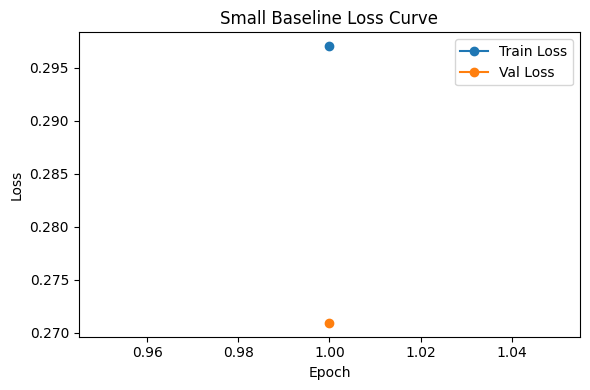

In [12]:
# 本代码块：保存 small 版结果并绘制 loss 曲线
small_exp["result_df"].to_csv("small_baseline_metrics.csv", index=False, encoding="utf-8-sig")
small_exp["overall_df"].to_csv("small_baseline_overall_metrics.csv", index=False, encoding="utf-8-sig")

plot_loss_curve(
    small_exp["train_losses"],
    small_exp["val_losses"],
    title="Small Baseline Loss Curve",
    save_path="small_baseline_loss_curve.png"
)


## 3. baseline 正式实验最小可行方案（medium版）


In [13]:
# 本代码块：运行 medium 版 baseline，作为正文中的主实验
medium_exp = run_experiment(
    exp_name="medium_baseline",
    train_subset_df=medium_train_df,
    test_subset_df=medium_test_df,
    batch_size=16,
    num_epochs=5,
    lr=1e-4,
    freeze_features=False,
    save_model_path="baseline_densenet121_medium.pth",
    log_every=50
)



===== Running experiment: medium_baseline =====
Loaded 10000 samples
Loaded 2000 samples

========== Epoch 1/5 ==========
[Train] Batch 0/625
[Train] Batch 50/625
[Train] Batch 100/625
[Train] Batch 150/625
[Train] Batch 200/625
[Train] Batch 250/625
[Train] Batch 300/625
[Train] Batch 350/625
[Train] Batch 400/625
[Train] Batch 450/625
[Train] Batch 500/625
[Train] Batch 550/625
[Train] Batch 600/625
[Val] Batch 0/125
[Val] Batch 50/125
[Val] Batch 100/125
Epoch [1/5] | Train Loss: 0.2053 | Val Loss: 0.2591 | Time: 1978.2s

========== Epoch 2/5 ==========
[Train] Batch 0/625
[Train] Batch 50/625
[Train] Batch 100/625
[Train] Batch 150/625
[Train] Batch 200/625
[Train] Batch 250/625
[Train] Batch 300/625
[Train] Batch 350/625
[Train] Batch 400/625
[Train] Batch 450/625
[Train] Batch 500/625
[Train] Batch 550/625
[Train] Batch 600/625
[Val] Batch 0/125
[Val] Batch 50/125
[Val] Batch 100/125
Epoch [2/5] | Train Loss: 0.1717 | Val Loss: 0.2540 | Time: 1916.9s

========== Epoch 3/5 ======

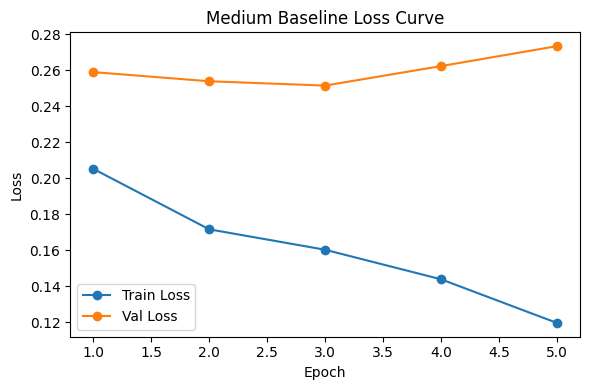

Mean AUC: 0.7035469924165478
Macro Precision: 0.27691695022894586
Micro Precision: 0.5356835769561479
Macro Recall: 0.08034523443191403
Micro Recall: 0.21241050119331742
Macro F1: 0.09880483486656343
Micro F1: 0.30419921875
Samples F1: 0.26944999999999997


In [14]:
# 本代码块：导出 medium 版实验结果并绘制 loss 曲线
medium_exp["result_df"].to_csv("baseline_medium_metrics.csv", index=False, encoding="utf-8-sig")
medium_exp["overall_df"].to_csv("baseline_medium_overall_metrics.csv", index=False, encoding="utf-8-sig")

plot_loss_curve(
    medium_exp["train_losses"],
    medium_exp["val_losses"],
    title="Medium Baseline Loss Curve",
    save_path="baseline_medium_loss_curve.png"
)

print("Mean AUC:", medium_exp["metrics"]["mean_auc"])
print("Macro Precision:", medium_exp["metrics"]["macro_precision"])
print("Micro Precision:", medium_exp["metrics"]["micro_precision"])
print("Macro Recall:", medium_exp["metrics"]["macro_recall"])
print("Micro Recall:", medium_exp["metrics"]["micro_recall"])
print("Macro F1:", medium_exp["metrics"]["macro_f1"])
print("Micro F1:", medium_exp["metrics"]["micro_f1"])
print("Samples F1:", medium_exp["metrics"]["samples_f1"])


In [15]:
# ============================================================
# 盲审补充实验 1：类别不平衡处理 + 类别阈值优化
# 建议运行位置：medium baseline 实验完成之后
# 主要输出：
# 1. medium_weighted_threshold_class_metrics.csv
# 2. medium_weighted_threshold_overall_metrics.csv
# 3. medium_class_best_thresholds.csv
# 4. medium_class_pos_weight.csv
# 5. medium_imbalance_threshold_overall_compare.csv
# 6. medium_minority_class_prf_compare.csv
# ============================================================

from sklearn.model_selection import train_test_split


def encode_label_string(label_string, class_names):
    """将 Finding Labels 字符串转换为 multi-hot 向量。"""
    label_vec = np.zeros(len(class_names), dtype=np.float32)
    for label in label_string.split("|"):
        if label in class_names:
            label_vec[class_names.index(label)] = 1.0
    return label_vec


def build_label_matrix(subset_df, class_names):
    """将 DataFrame 中的 Finding Labels 全部转换为标签矩阵。"""
    label_matrix = np.stack([
        encode_label_string(label_string, class_names)
        for label_string in subset_df["Finding Labels"].values
    ])
    return label_matrix


def compute_pos_weight_from_df(train_subset_df, class_names, max_weight=20.0):
    """
    根据训练集各类别阳性/阴性数量计算 BCEWithLogitsLoss 的 pos_weight。

    pos_weight_i = 阴性样本数 / 阳性样本数

    说明：
    1. 少数类阳性样本少，pos_weight 会更大；
    2. max_weight 用于避免极少数类权重过大导致训练不稳定；
    3. 返回 torch.Tensor，可直接传入 nn.BCEWithLogitsLoss(pos_weight=...)。
    """
    label_matrix = build_label_matrix(train_subset_df, class_names)

    pos_counts = label_matrix.sum(axis=0)
    neg_counts = label_matrix.shape[0] - pos_counts

    pos_weight = neg_counts / np.maximum(pos_counts, 1.0)
    pos_weight = np.clip(pos_weight, 1.0, max_weight)

    pos_weight_tensor = torch.tensor(pos_weight, dtype=torch.float32).to(device)

    weight_df = pd.DataFrame({
        "Class": class_names,
        "Positive Count": pos_counts.astype(int),
        "Negative Count": neg_counts.astype(int),
        "Pos Weight": pos_weight
    }).sort_values(by="Positive Count", ascending=True)

    return pos_weight_tensor, weight_df


def make_class_threshold_array(thresholds, class_names):
    """
    将阈值统一转换为 numpy array。
    支持三种输入：
    1. 单个 float，例如 0.5；
    2. dict，例如 {'Effusion': 0.35, ...}；
    3. list / np.array，长度等于类别数。
    """
    if isinstance(thresholds, (float, int)):
        return np.array([float(thresholds)] * len(class_names), dtype=np.float32)

    if isinstance(thresholds, dict):
        return np.array([float(thresholds[c]) for c in class_names], dtype=np.float32)

    thresholds = np.array(thresholds, dtype=np.float32)
    assert len(thresholds) == len(class_names), "阈值数量必须与类别数一致"
    return thresholds


def evaluate_multilabel_metrics_with_thresholds(all_labels_np, all_probs, class_names, thresholds=0.5):
    """
    支持类别特异性阈值的多标签评价函数。
    thresholds 可以是固定阈值，也可以是每类不同阈值。
    """
    threshold_array = make_class_threshold_array(thresholds, class_names)
    all_preds = (all_probs >= threshold_array.reshape(1, -1)).astype(int)

    auc_per_class = {}
    precision_per_class = {}
    recall_per_class = {}
    f1_per_class = {}
    valid_auc_list = []

    for i, cls_name in enumerate(class_names):
        y_true = all_labels_np[:, i]
        y_score = all_probs[:, i]
        y_pred = all_preds[:, i]

        if len(np.unique(y_true)) < 2:
            auc_i = np.nan
        else:
            auc_i = roc_auc_score(y_true, y_score)
            valid_auc_list.append(auc_i)

        auc_per_class[cls_name] = auc_i
        precision_per_class[cls_name] = precision_score(y_true, y_pred, zero_division=0)
        recall_per_class[cls_name] = recall_score(y_true, y_pred, zero_division=0)
        f1_per_class[cls_name] = f1_score(y_true, y_pred, zero_division=0)

    metrics = {
        "mean_auc": np.mean(valid_auc_list) if len(valid_auc_list) > 0 else np.nan,
        "macro_precision": precision_score(all_labels_np, all_preds, average="macro", zero_division=0),
        "micro_precision": precision_score(all_labels_np, all_preds, average="micro", zero_division=0),
        "macro_recall": recall_score(all_labels_np, all_preds, average="macro", zero_division=0),
        "micro_recall": recall_score(all_labels_np, all_preds, average="micro", zero_division=0),
        "macro_f1": f1_score(all_labels_np, all_preds, average="macro", zero_division=0),
        "micro_f1": f1_score(all_labels_np, all_preds, average="micro", zero_division=0),
        "samples_f1": f1_score(all_labels_np, all_preds, average="samples", zero_division=0),
        "auc_per_class": auc_per_class,
        "precision_per_class": precision_per_class,
        "recall_per_class": recall_per_class,
        "f1_per_class": f1_per_class,
        "thresholds": threshold_array,
        "all_preds": all_preds
    }

    return metrics


def find_best_thresholds_by_class(y_true, y_prob, class_names, threshold_grid=None):
    """
    在验证集上为每个类别单独搜索使 F1 最大的分类阈值。
    注意：阈值优化应该在验证集上完成，不建议直接在测试集上找最优阈值。
    """
    if threshold_grid is None:
        threshold_grid = np.arange(0.05, 0.96, 0.05)

    records = []
    best_thresholds = {}

    for i, cls_name in enumerate(class_names):
        best_t = 0.5
        best_f1 = -1.0
        best_precision = 0.0
        best_recall = 0.0

        for t in threshold_grid:
            y_pred = (y_prob[:, i] >= t).astype(int)

            precision_i = precision_score(y_true[:, i], y_pred, zero_division=0)
            recall_i = recall_score(y_true[:, i], y_pred, zero_division=0)
            f1_i = f1_score(y_true[:, i], y_pred, zero_division=0)

            if f1_i > best_f1:
                best_f1 = f1_i
                best_t = float(t)
                best_precision = precision_i
                best_recall = recall_i

        best_thresholds[cls_name] = best_t
        records.append({
            "Class": cls_name,
            "Best Threshold": best_t,
            "Validation Precision": best_precision,
            "Validation Recall": best_recall,
            "Validation F1": best_f1
        })

    threshold_df = pd.DataFrame(records)
    return best_thresholds, threshold_df


def make_result_tables_with_thresholds(metrics, class_names):
    """根据增强版 metrics 生成类别结果表和总体结果表。"""
    result_df = pd.DataFrame({
        "Class": class_names,
        "Threshold": metrics["thresholds"],
        "AUC": [metrics["auc_per_class"][c] for c in class_names],
        "Precision": [metrics["precision_per_class"][c] for c in class_names],
        "Recall": [metrics["recall_per_class"][c] for c in class_names],
        "F1": [metrics["f1_per_class"][c] for c in class_names],
    }).sort_values(by="AUC", ascending=False)

    overall_df = pd.DataFrame({
        "Metric": [
            "Mean AUC",
            "Macro Precision",
            "Micro Precision",
            "Macro Recall",
            "Micro Recall",
            "Macro F1",
            "Micro F1",
            "Samples F1"
        ],
        "Value": [
            metrics["mean_auc"],
            metrics["macro_precision"],
            metrics["micro_precision"],
            metrics["macro_recall"],
            metrics["micro_recall"],
            metrics["macro_f1"],
            metrics["micro_f1"],
            metrics["samples_f1"]
        ]
    })

    return result_df, overall_df


def run_experiment_with_imbalance_and_threshold(
    exp_name,
    train_subset_df,
    test_subset_df,
    batch_size=16,
    num_epochs=3,
    lr=1e-4,
    freeze_features=False,
    use_pos_weight=True,
    optimize_threshold=True,
    val_size=0.2,
    random_state=42,
    save_model_path=None,
    log_every=50
):
    """
    完整增强实验流程：
    1. 从训练集内部划分 train_inner / val_inner；
    2. 使用 train_inner 训练模型；
    3. 在 val_inner 上搜索每个类别的最优阈值；
    4. 在 test_subset_df 上进行最终测试；
    5. 输出总体指标、每类指标、阈值表、类别权重表。
    """
    print(f"\n===== Running enhanced experiment: {exp_name} =====")

    train_inner_df, val_inner_df = train_test_split(
        train_subset_df,
        test_size=val_size,
        random_state=random_state,
        shuffle=True
    )

    train_inner_df = train_inner_df.reset_index(drop=True)
    val_inner_df = val_inner_df.reset_index(drop=True)
    test_subset_df = test_subset_df.reset_index(drop=True)

    print("Train inner size:", len(train_inner_df))
    print("Validation inner size:", len(val_inner_df))
    print("Test size:", len(test_subset_df))

    train_dataset = CXR8Dataset(train_inner_df, img_dir, label_map, transform=transform)
    val_dataset = CXR8Dataset(val_inner_df, img_dir, label_map, transform=transform)
    test_dataset = CXR8Dataset(test_subset_df, img_dir, label_map, transform=transform)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

    model = build_model(
        num_classes=len(all_labels),
        device=device,
        freeze_features=freeze_features,
        pretrained=True
    )

    if use_pos_weight:
        pos_weight_tensor, pos_weight_df = compute_pos_weight_from_df(
            train_inner_df,
            all_labels,
            max_weight=20.0
        )
        criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight_tensor)
        print("Use Weighted BCEWithLogitsLoss")
    else:
        pos_weight_df = None
        criterion = nn.BCEWithLogitsLoss()
        print("Use standard BCEWithLogitsLoss")

    optimizer = build_optimizer(model, lr=lr, freeze_features=freeze_features)

    model, train_losses, val_losses, best_val_loss = fit_model(
        model=model,
        train_loader=train_loader,
        test_loader=val_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device,
        num_epochs=num_epochs,
        log_every=log_every
    )

    if save_model_path is not None:
        torch.save(model.state_dict(), save_model_path)
        print("Model saved:", save_model_path)

    val_probs, val_labels_np = collect_predictions(model, val_loader, device, log_every=log_every)

    if optimize_threshold:
        best_thresholds, threshold_df = find_best_thresholds_by_class(
            val_labels_np,
            val_probs,
            all_labels
        )
        thresholds_for_test = best_thresholds
        print("Use class-specific optimized thresholds")
    else:
        threshold_df = pd.DataFrame({"Class": all_labels, "Best Threshold": [0.5] * len(all_labels)})
        thresholds_for_test = 0.5
        print("Use fixed threshold = 0.5")

    test_probs, test_labels_np = collect_predictions(model, test_loader, device, log_every=log_every)

    metrics = evaluate_multilabel_metrics_with_thresholds(
        test_labels_np,
        test_probs,
        all_labels,
        thresholds=thresholds_for_test
    )

    result_df, overall_df = make_result_tables_with_thresholds(metrics, all_labels)

    return {
        "exp_name": exp_name,
        "model": model,
        "train_inner_df": train_inner_df,
        "val_inner_df": val_inner_df,
        "test_df": test_subset_df,
        "train_dataset": train_dataset,
        "val_dataset": val_dataset,
        "test_dataset": test_dataset,
        "train_loader": train_loader,
        "val_loader": val_loader,
        "test_loader": test_loader,
        "train_losses": train_losses,
        "val_losses": val_losses,
        "best_val_loss": best_val_loss,
        "val_probs": val_probs,
        "val_labels_np": val_labels_np,
        "all_probs": test_probs,
        "all_labels_np": test_labels_np,
        "metrics": metrics,
        "result_df": result_df,
        "overall_df": overall_df,
        "threshold_df": threshold_df,
        "pos_weight_df": pos_weight_df
    }


# 运行增强实验：Weighted BCE + 类别阈值优化
medium_weighted_threshold_exp = run_experiment_with_imbalance_and_threshold(
    exp_name="medium_weighted_bce_threshold",
    train_subset_df=medium_train_df,
    test_subset_df=medium_test_df,
    batch_size=16,
    num_epochs=5,
    lr=1e-4,
    freeze_features=False,
    use_pos_weight=True,
    optimize_threshold=True,
    val_size=0.2,
    save_model_path="densenet121_medium_weighted_threshold.pth",
    log_every=50
)

# 导出增强实验结果
medium_weighted_threshold_exp["result_df"].to_csv(
    "medium_weighted_threshold_class_metrics.csv",
    index=False,
    encoding="utf-8-sig"
)

medium_weighted_threshold_exp["overall_df"].to_csv(
    "medium_weighted_threshold_overall_metrics.csv",
    index=False,
    encoding="utf-8-sig"
)

medium_weighted_threshold_exp["threshold_df"].to_csv(
    "medium_class_best_thresholds.csv",
    index=False,
    encoding="utf-8-sig"
)

if medium_weighted_threshold_exp["pos_weight_df"] is not None:
    medium_weighted_threshold_exp["pos_weight_df"].to_csv(
        "medium_class_pos_weight.csv",
        index=False,
        encoding="utf-8-sig"
    )

print("Weighted BCE + threshold optimization overall metrics:")
display(medium_weighted_threshold_exp["overall_df"])


def extract_overall_metrics_for_compare(exp_name, exp_dict):
    metrics = exp_dict["metrics"]
    return {
        "Experiment": exp_name,
        "Mean AUC": metrics["mean_auc"],
        "Macro Precision": metrics["macro_precision"],
        "Macro Recall": metrics["macro_recall"],
        "Macro F1": metrics["macro_f1"],
        "Micro Precision": metrics["micro_precision"],
        "Micro Recall": metrics["micro_recall"],
        "Micro F1": metrics["micro_f1"],
        "Samples F1": metrics["samples_f1"]
    }


compare_records = []
compare_records.append(
    extract_overall_metrics_for_compare("BCE + fixed threshold 0.5", medium_exp)
)
compare_records.append(
    extract_overall_metrics_for_compare("Weighted BCE + class-specific thresholds", medium_weighted_threshold_exp)
)

overall_compare_df = pd.DataFrame(compare_records)
overall_compare_df.to_csv(
    "medium_imbalance_threshold_overall_compare.csv",
    index=False,
    encoding="utf-8-sig"
)

display(overall_compare_df)


def get_minority_classes(train_subset_df, class_names, top_k=6):
    """根据训练集中阳性样本数量，选出样本数量最少的若干疾病类别，默认排除 No Finding。"""
    dist_df = summarize_label_distribution(train_subset_df, class_names)
    dist_df = dist_df[dist_df["Class"] != "No Finding"].copy()
    dist_df = dist_df.sort_values(by="Count", ascending=True)
    return dist_df.head(top_k)["Class"].tolist(), dist_df


minority_classes, full_dist_df = get_minority_classes(medium_train_df, all_labels, top_k=6)
print("少数类疾病：", minority_classes)


def build_minority_compare_table(exp_dict_a, exp_name_a, exp_dict_b, exp_name_b, minority_classes):
    """对比两个实验在少数类上的 Precision / Recall / F1。"""
    rows = []

    for cls_name in minority_classes:
        rows.append({
            "Class": cls_name,
            f"{exp_name_a} Precision": exp_dict_a["metrics"]["precision_per_class"][cls_name],
            f"{exp_name_a} Recall": exp_dict_a["metrics"]["recall_per_class"][cls_name],
            f"{exp_name_a} F1": exp_dict_a["metrics"]["f1_per_class"][cls_name],
            f"{exp_name_b} Precision": exp_dict_b["metrics"]["precision_per_class"][cls_name],
            f"{exp_name_b} Recall": exp_dict_b["metrics"]["recall_per_class"][cls_name],
            f"{exp_name_b} F1": exp_dict_b["metrics"]["f1_per_class"][cls_name],
            "F1 Change": (
                exp_dict_b["metrics"]["f1_per_class"][cls_name]
                - exp_dict_a["metrics"]["f1_per_class"][cls_name]
            )
        })

    return pd.DataFrame(rows)


minority_compare_df = build_minority_compare_table(
    exp_dict_a=medium_exp,
    exp_name_a="BCE_0.5",
    exp_dict_b=medium_weighted_threshold_exp,
    exp_name_b="Weighted_Threshold",
    minority_classes=minority_classes
)

minority_compare_df.to_csv(
    "medium_minority_class_prf_compare.csv",
    index=False,
    encoding="utf-8-sig"
)

display(minority_compare_df)



===== Running enhanced experiment: medium_weighted_bce_threshold =====
Train inner size: 8000
Validation inner size: 2000
Test size: 2000
Loaded 8000 samples
Loaded 2000 samples
Loaded 2000 samples
Use Weighted BCEWithLogitsLoss

========== Epoch 1/5 ==========
[Train] Batch 0/500
[Train] Batch 50/500
[Train] Batch 100/500
[Train] Batch 150/500
[Train] Batch 200/500
[Train] Batch 250/500
[Train] Batch 300/500
[Train] Batch 350/500
[Train] Batch 400/500
[Train] Batch 450/500
[Val] Batch 0/125
[Val] Batch 50/125
[Val] Batch 100/125
Epoch [1/5] | Train Loss: 0.8463 | Val Loss: 0.8630 | Time: 1549.3s

========== Epoch 2/5 ==========
[Train] Batch 0/500
[Train] Batch 50/500
[Train] Batch 100/500
[Train] Batch 150/500
[Train] Batch 200/500
[Train] Batch 250/500
[Train] Batch 300/500
[Train] Batch 350/500
[Train] Batch 400/500
[Train] Batch 450/500
[Val] Batch 0/125
[Val] Batch 50/125
[Val] Batch 100/125
Epoch [2/5] | Train Loss: 0.7438 | Val Loss: 0.8217 | Time: 1548.0s

========== Epoch 3/

,Metric,Value
0,Mean AUC,0.732576
1,Macro Precision,0.196863
2,Micro Precision,0.242835
3,Macro Recall,0.413692
4,Micro Recall,0.537334
5,Macro F1,0.245036
6,Micro F1,0.334501
7,Samples F1,0.365759


,Experiment,Mean AUC,Macro Precision,Macro Recall,Macro F1,Micro Precision,Micro Recall,Micro F1,Samples F1
0,BCE + fixed threshold 0.5,0.703547,0.276917,0.080345,0.098805,0.535684,0.212411,0.304199,0.269450
1,Weighted BCE + class-specific thresholds,0.732576,0.196863,0.413692,0.245036,0.242835,0.537334,0.334501,0.365759


少数类疾病： ['Hernia', 'Pneumonia', 'Edema', 'Fibrosis', 'Emphysema', 'Cardiomegaly']


,Class,BCE_0.5 Precision,BCE_0.5 Recall,BCE_0.5 F1,Weighted_Threshold Precision,Weighted_Threshold Recall,Weighted_Threshold F1,F1 Change
0,Hernia,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,Pneumonia,0.0,0.000000,0.000000,0.034409,0.744186,0.065776,0.065776
2,Edema,0.0,0.000000,0.000000,0.109705,0.351351,0.167203,0.167203
3,Fibrosis,0.0,0.000000,0.000000,0.064000,0.210526,0.098160,0.098160
4,Emphysema,1.0,0.020833,0.040816,0.275862,0.250000,0.262295,0.221479
5,Cardiomegaly,0.0,0.000000,0.000000,0.135484,0.466667,0.210000,0.210000


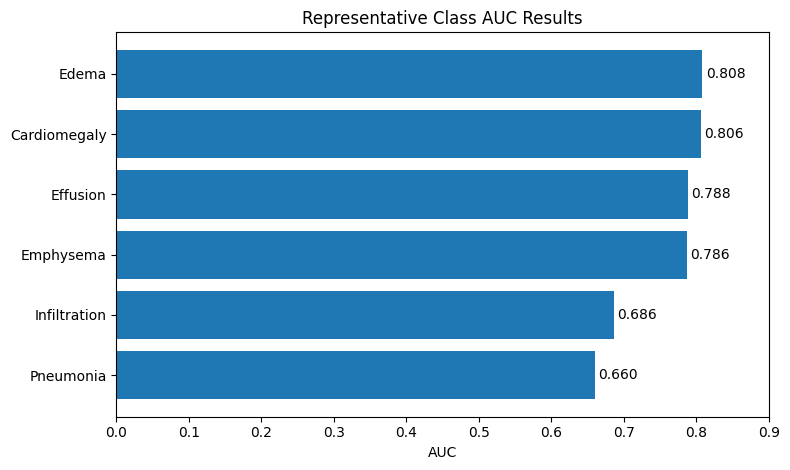

,Class,Count
10,No Finding,5833
8,Infiltration,1584
0,Atelectasis,987
4,Effusion,985
11,Nodule,545
9,Mass,434
2,Consolidation,352
14,Pneumothorax,300
12,Pleural_Thickening,280
1,Cardiomegaly,220


In [16]:
# 本代码块：绘制代表性类别 AUC 柱状图并统计 medium 版标签分布
selected_classes = [
    "Cardiomegaly",
    "Edema",
    "Emphysema",
    "Effusion",
    "Infiltration",
    "Pneumonia"
]

plot_selected_auc(
    medium_exp["result_df"],
    selected_classes=selected_classes,
    title="Representative Class AUC Results",
    save_path="representative_auc_bar.png"
)

dist_df = summarize_label_distribution(medium_train_df, all_labels)
dist_df.head(10)


## 4. full 版 1 epoch


In [ ]:
# 本代码块：运行 full 版 1 epoch，建议 CPU 上将 batch_size 设为 8
full_exp = run_experiment(
    exp_name="full_1epoch",
    train_subset_df=train_df,
    test_subset_df=test_df,
    batch_size=8,
    num_epochs=1,
    lr=1e-4,
    freeze_features=False,
    save_model_path="baseline_densenet121_full_1epoch.pth",
    log_every=200
)


In [ ]:
# 本代码块：查看 full 版 1 epoch 的总体指标并绘制 loss 曲线
full_exp["result_df"].to_csv("baseline_full_1epoch_metrics.csv", index=False, encoding="utf-8-sig")
full_exp["overall_df"].to_csv("baseline_full_1epoch_overall_metrics.csv", index=False, encoding="utf-8-sig")

plot_loss_curve(
    full_exp["train_losses"],
    full_exp["val_losses"],
    title="Full 1-Epoch Loss Curve",
    save_path="baseline_full_1epoch_loss_curve.png"
)

full_exp["overall_df"]


## 5. Grad-CAM 可视化生成典型病例


In [17]:
# 本代码块：加载 medium 版训练好的模型，供 Grad-CAM 与解释分析使用
def load_trained_model(weights_path, device, num_classes):
    model = build_model(num_classes=num_classes, device=device, freeze_features=False, pretrained=False)
    model.load_state_dict(torch.load(weights_path, map_location=device))
    model.eval()
    return model

clean_model = load_trained_model("baseline_densenet121_medium.pth", device, len(all_labels))
print("Clean model loaded.")


Clean model loaded.


In [18]:
# 本代码块：关闭 inplace ReLU，定义 Grad-CAM 与热力图叠加函数
def replace_relu_inplace(module):
    for name, child in module.named_children():
        if isinstance(child, nn.ReLU):
            setattr(module, name, nn.ReLU(inplace=False))
        else:
            replace_relu_inplace(child)

replace_relu_inplace(clean_model)
print("All inplace ReLU replaced.")


class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None
        self.forward_hook = self.target_layer.register_forward_hook(self._forward_hook)

    def _forward_hook(self, module, inputs, output):
        self.activations = output

        def _tensor_hook(grad):
            self.gradients = grad

        output.register_hook(_tensor_hook)

    def generate(self, input_tensor, class_idx):
        self.model.eval()
        self.model.zero_grad()

        output = self.model(input_tensor)
        score = output[:, class_idx]
        score.backward(retain_graph=True)

        gradients = self.gradients
        activations = self.activations

        weights = gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * activations).sum(dim=1, keepdim=True)
        cam = F.relu(cam)

        cam = cam.squeeze().detach().cpu().numpy()
        cam = cam - cam.min()
        if cam.max() > 0:
            cam = cam / cam.max()

        return cam

    def remove_hooks(self):
        self.forward_hook.remove()


def denormalize_image(tensor, mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]):
    image = tensor.clone().cpu().numpy().transpose(1, 2, 0)
    mean = np.array(mean)
    std = np.array(std)
    image = image * std + mean
    image = np.clip(image, 0, 1)
    return image


def show_cam_on_image(img, cam, alpha=0.4):
    h, w, _ = img.shape
    cam_img = Image.fromarray(np.uint8(cam * 255)).resize((w, h), resample=Image.BILINEAR)
    cam_resized = np.array(cam_img) / 255.0

    cmap = plt.get_cmap("jet")
    heatmap = cmap(cam_resized)[:, :, :3]

    overlay = (1 - alpha) * img + alpha * heatmap
    overlay = np.clip(overlay, 0, 1)
    return cam_resized, heatmap, overlay


All inplace ReLU replaced.


In [19]:
# 本代码块：基于 medium 测试集筛选适合做 Grad-CAM 的典型阳性病例
def find_typical_cases(
    all_probs,
    all_labels_np,
    class_names,
    target_classes=None,
    min_prob=0.30,
    top_k_per_class=3
):
    if target_classes is None:
        target_classes = ["Infiltration", "Effusion", "Atelectasis"]

    class_to_idx = {c: i for i, c in enumerate(class_names)}
    selected = []

    for cls_name in target_classes:
        cls_idx = class_to_idx[cls_name]
        candidates = []

        for i in range(len(all_probs)):
            if all_labels_np[i, cls_idx] == 1:
                prob = all_probs[i, cls_idx]
                if prob >= min_prob:
                    candidates.append({
                        "sample_idx": i,
                        "class_idx": cls_idx,
                        "class_name": cls_name,
                        "prob": float(prob)
                    })

        candidates = sorted(candidates, key=lambda x: x["prob"], reverse=True)
        selected.extend(candidates[:top_k_per_class])

    return selected


typical_cases = find_typical_cases(
    medium_exp["all_probs"],
    medium_exp["all_labels_np"],
    all_labels,
    target_classes=["Infiltration", "Effusion", "Atelectasis"],
    min_prob=0.30,
    top_k_per_class=3
)

print("选出的典型病例数：", len(typical_cases))
for case in typical_cases:
    print(case)


选出的典型病例数： 9
{'sample_idx': 206, 'class_idx': 8, 'class_name': 'Infiltration', 'prob': 0.7206991314888}
{'sample_idx': 1568, 'class_idx': 8, 'class_name': 'Infiltration', 'prob': 0.7132143974304199}
{'sample_idx': 935, 'class_idx': 8, 'class_name': 'Infiltration', 'prob': 0.6827101707458496}
{'sample_idx': 1047, 'class_idx': 4, 'class_name': 'Effusion', 'prob': 0.9626861214637756}
{'sample_idx': 172, 'class_idx': 4, 'class_name': 'Effusion', 'prob': 0.9573109149932861}
{'sample_idx': 168, 'class_idx': 4, 'class_name': 'Effusion', 'prob': 0.9524224996566772}
{'sample_idx': 1737, 'class_idx': 0, 'class_name': 'Atelectasis', 'prob': 0.7717853784561157}
{'sample_idx': 1088, 'class_idx': 0, 'class_name': 'Atelectasis', 'prob': 0.6936652660369873}
{'sample_idx': 383, 'class_idx': 0, 'class_name': 'Atelectasis', 'prob': 0.6909557580947876}


每种类型最终选中的典型病例：
{'sample_idx': 206, 'class_idx': 8, 'class_name': 'Infiltration', 'prob': 0.7206991314888}
{'sample_idx': 1047, 'class_idx': 4, 'class_name': 'Effusion', 'prob': 0.9626861214637756}
{'sample_idx': 1737, 'class_idx': 0, 'class_name': 'Atelectasis', 'prob': 0.7717853784561157}
Sample index: 206
True classes: ['Effusion', 'Infiltration']
Target class: Infiltration
Pred prob (Infiltration): 0.7207


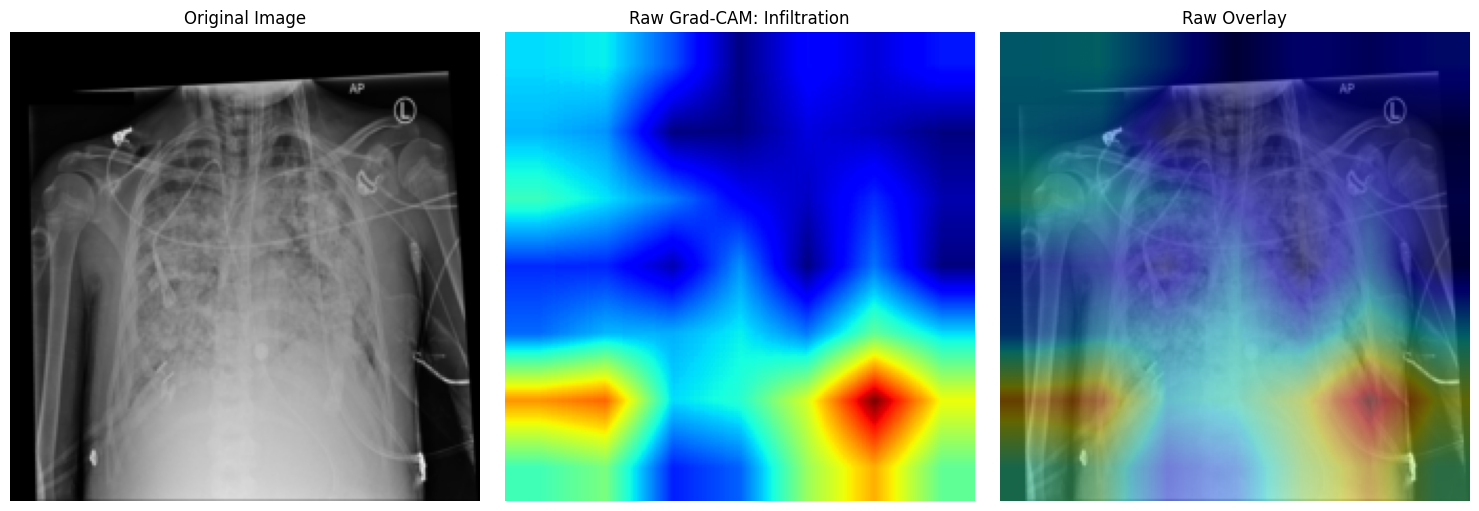

Saved to: typical_raw_cases\raw_typical_infiltration.png
Sample index: 1047
True classes: ['Effusion']
Target class: Effusion
Pred prob (Effusion): 0.9627


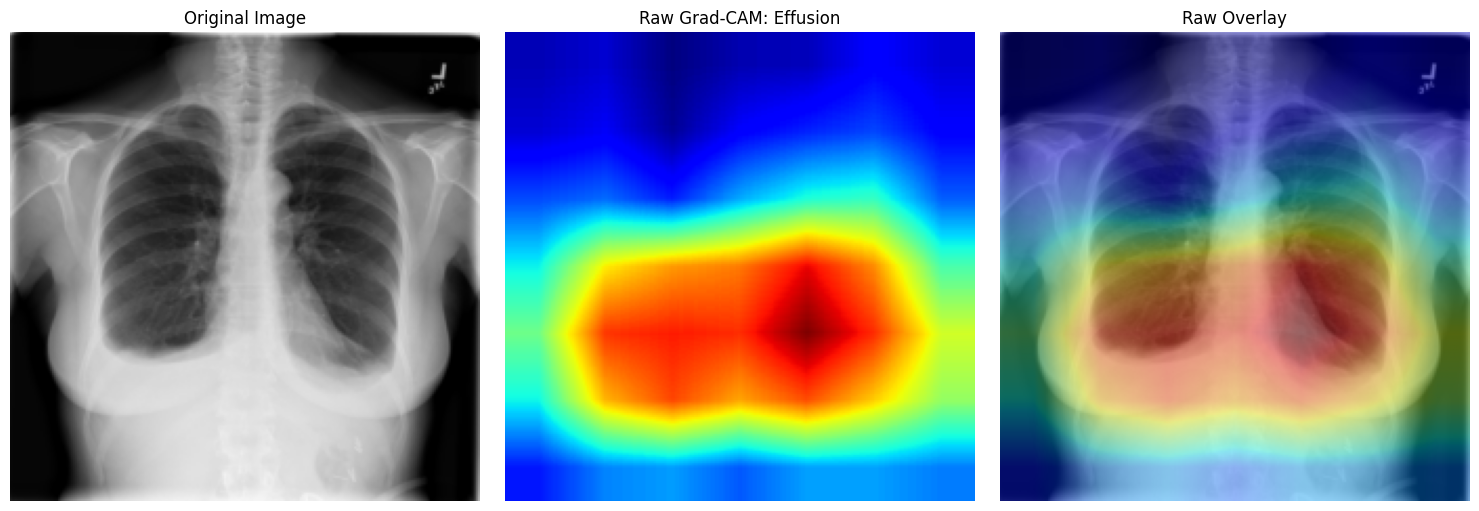

Saved to: typical_raw_cases\raw_typical_effusion.png
Sample index: 1737
True classes: ['Atelectasis']
Target class: Atelectasis
Pred prob (Atelectasis): 0.7718


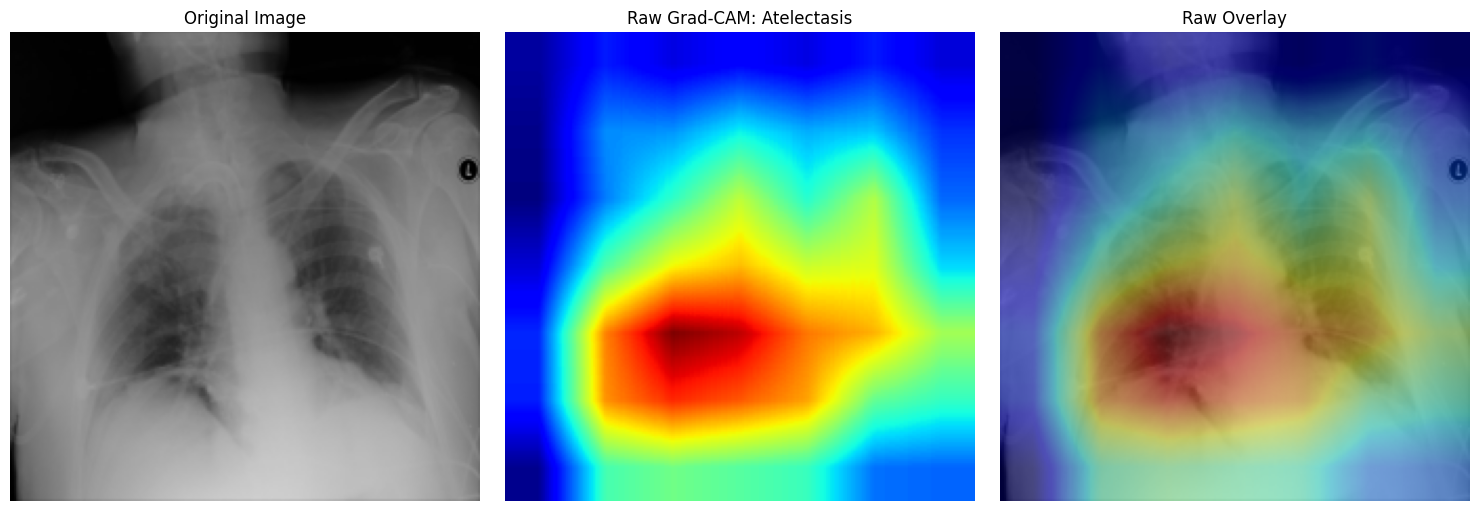

Saved to: typical_raw_cases\raw_typical_atelectasis.png


In [20]:
# 本代码块：输出每种类型的典型病例图各一个，供 4.1.3 原始热力图典型现象分析使用
def select_one_case_per_class(typical_cases):
    selected = {}
    for case in typical_cases:
        cls = case["class_name"]
        if cls not in selected or case["prob"] > selected[cls]["prob"]:
            selected[cls] = case
    return selected


def visualize_raw_typical_case(
    model,
    dataset,
    device,
    class_names,
    sample_idx,
    target_class_idx,
    save_dir=None,
    file_prefix="raw_typical"
):
    image_tensor, label_tensor = dataset[sample_idx]
    input_tensor = image_tensor.unsqueeze(0).to(device)

    logits = model(input_tensor)
    probs = torch.sigmoid(logits).squeeze(0).detach().cpu().numpy()

    true_indices = np.where(label_tensor.numpy() == 1)[0].tolist()
    true_classes = [class_names[i] for i in true_indices]
    target_class_name = class_names[target_class_idx]

    target_layer = model.features.denseblock4.denselayer16.conv2
    gradcam = GradCAM(model, target_layer)
    cam_raw = gradcam.generate(input_tensor, target_class_idx)
    gradcam.remove_hooks()

    img = denormalize_image(image_tensor)
    cam_raw_resized, _, overlay_raw = show_cam_on_image(img, cam_raw)

    print(f"Sample index: {sample_idx}")
    print("True classes:", true_classes)
    print("Target class:", target_class_name)
    print(f"Pred prob ({target_class_name}): {probs[target_class_idx]:.4f}")

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    axes[0].imshow(img)
    axes[0].set_title("Original Image")
    axes[0].axis("off")

    axes[1].imshow(cam_raw_resized, cmap="jet")
    axes[1].set_title(f"Raw Grad-CAM: {target_class_name}")
    axes[1].axis("off")

    axes[2].imshow(overlay_raw)
    axes[2].set_title("Raw Overlay")
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()

    if save_dir is not None:
        os.makedirs(save_dir, exist_ok=True)
        save_path = os.path.join(save_dir, f"{file_prefix}_{target_class_name.lower()}.png")
        fig.savefig(save_path, dpi=300, bbox_inches="tight")
        print("Saved to:", save_path)

    return fig


selected_cases = select_one_case_per_class(typical_cases)

print("每种类型最终选中的典型病例：")
for cls_name in ["Infiltration", "Effusion", "Atelectasis"]:
    if cls_name in selected_cases:
        print(selected_cases[cls_name])

save_dir = "typical_raw_cases"

for cls_name in ["Infiltration", "Effusion", "Atelectasis"]:
    if cls_name in selected_cases:
        case = selected_cases[cls_name]
        _ = visualize_raw_typical_case(
            model=clean_model,
            dataset=medium_exp["test_dataset"],
            device=device,
            class_names=all_labels,
            sample_idx=case["sample_idx"],
            target_class_idx=case["class_idx"],
            save_dir=save_dir,
            file_prefix="raw_typical"
        )


## 6. 区域约束改进：先做一个轻量可落地版本


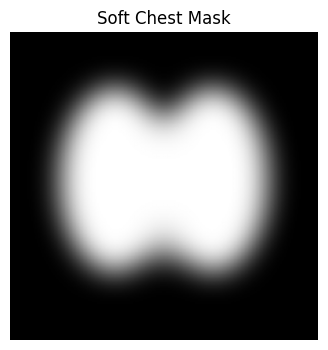

In [21]:
# 本代码块：生成胸腔中心软约束 mask，并定义区域约束与可视化函数
def create_soft_chest_mask(h=224, w=224):
    yy, xx = np.mgrid[0:h, 0:w]

    cx1, cy1 = int(w * 0.34), int(h * 0.48)
    rx1, ry1 = int(w * 0.18), int(h * 0.30)
    left_lung = ((xx - cx1) / rx1) ** 2 + ((yy - cy1) / ry1) ** 2

    cx2, cy2 = int(w * 0.66), int(h * 0.48)
    rx2, ry2 = int(w * 0.18), int(h * 0.30)
    right_lung = ((xx - cx2) / rx2) ** 2 + ((yy - cy2) / ry2) ** 2

    cx3, cy3 = int(w * 0.50), int(h * 0.50)
    rx3, ry3 = int(w * 0.10), int(h * 0.25)
    center_region = ((xx - cx3) / rx3) ** 2 + ((yy - cy3) / ry3) ** 2

    mask = np.zeros((h, w), dtype=np.float32)
    mask[left_lung <= 1] = 1.0
    mask[right_lung <= 1] = 1.0
    mask[center_region <= 1] = np.maximum(mask[center_region <= 1], 0.6)

    mask_img = Image.fromarray(np.uint8(mask * 255))
    mask_img = mask_img.filter(ImageFilter.GaussianBlur(radius=10))
    mask = np.array(mask_img).astype(np.float32) / 255.0

    mask = mask - mask.min()
    if mask.max() > 0:
        mask = mask / mask.max()

    return mask


def apply_region_constraint(cam, mask):
    h, w = mask.shape
    cam_img = Image.fromarray(np.uint8(cam * 255))
    cam_img = cam_img.resize((w, h), resample=Image.BILINEAR)
    cam_resized = np.array(cam_img).astype(np.float32) / 255.0

    cam_rc = cam_resized * mask
    cam_rc = cam_rc - cam_rc.min()
    if cam_rc.max() > 0:
        cam_rc = cam_rc / cam_rc.max()

    return cam_rc


def visualize_case_with_region_constraint(
    model,
    dataset,
    device,
    class_names,
    sample_idx,
    target_class_idx,
    chest_mask
):
    image_tensor, label_tensor = dataset[sample_idx]
    input_tensor = image_tensor.unsqueeze(0).to(device)

    logits = model(input_tensor)
    probs = torch.sigmoid(logits).squeeze(0).detach().cpu().numpy()

    true_indices = np.where(label_tensor.numpy() == 1)[0].tolist()
    true_classes = [class_names[i] for i in true_indices]
    target_class_name = class_names[target_class_idx]

    target_layer = model.features.denseblock4.denselayer16.conv2
    gradcam = GradCAM(model, target_layer)
    cam_raw = gradcam.generate(input_tensor, target_class_idx)
    gradcam.remove_hooks()

    cam_rc = apply_region_constraint(cam_raw, chest_mask)

    img = denormalize_image(image_tensor)
    cam_raw_resized, _, overlay_raw = show_cam_on_image(img, cam_raw)
    cam_rc_resized, _, overlay_rc = show_cam_on_image(img, cam_rc)

    print(f"Sample index: {sample_idx}")
    print("True classes:", true_classes)
    print("Target class:", target_class_name)
    print(f"Pred prob ({target_class_name}): {probs[target_class_idx]:.4f}")

    fig, axes = plt.subplots(2, 3, figsize=(15, 9))

    axes[0, 0].imshow(img)
    axes[0, 0].set_title("Original Image")
    axes[0, 0].axis("off")

    axes[0, 1].imshow(cam_raw_resized, cmap="jet")
    axes[0, 1].set_title(f"Raw Grad-CAM: {target_class_name}")
    axes[0, 1].axis("off")

    axes[0, 2].imshow(overlay_raw)
    axes[0, 2].set_title("Raw Overlay")
    axes[0, 2].axis("off")

    axes[1, 0].imshow(chest_mask, cmap="gray")
    axes[1, 0].set_title("Chest Region Mask")
    axes[1, 0].axis("off")

    axes[1, 1].imshow(cam_rc_resized, cmap="jet")
    axes[1, 1].set_title("Region-Constrained CAM")
    axes[1, 1].axis("off")

    axes[1, 2].imshow(overlay_rc)
    axes[1, 2].set_title("Region-Constrained Overlay")
    axes[1, 2].axis("off")

    plt.tight_layout()
    plt.show()

    return {
        "sample_idx": sample_idx,
        "true_classes": true_classes,
        "target_class_name": target_class_name,
        "prob": probs[target_class_idx],
        "cam_raw": cam_raw,
        "cam_rc": cam_rc
    }


chest_mask = create_soft_chest_mask(224, 224)

plt.figure(figsize=(4, 4))
plt.imshow(chest_mask, cmap="gray")
plt.title("Soft Chest Mask")
plt.axis("off")
plt.show()


Sample index: 206
True classes: ['Effusion', 'Infiltration']
Target class: Infiltration
Pred prob (Infiltration): 0.7207


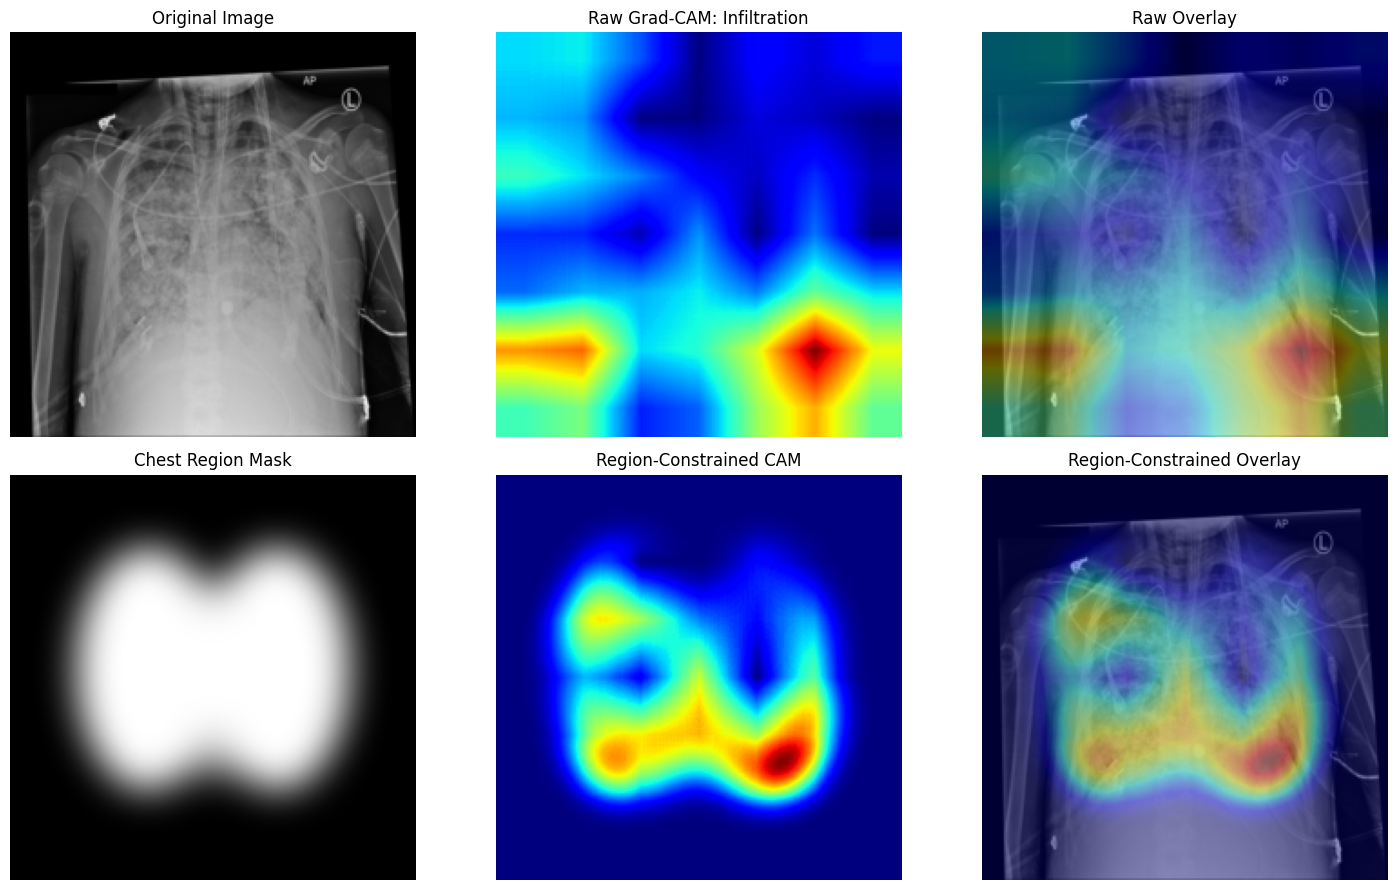

Sample index: 1568
True classes: ['Infiltration']
Target class: Infiltration
Pred prob (Infiltration): 0.7132


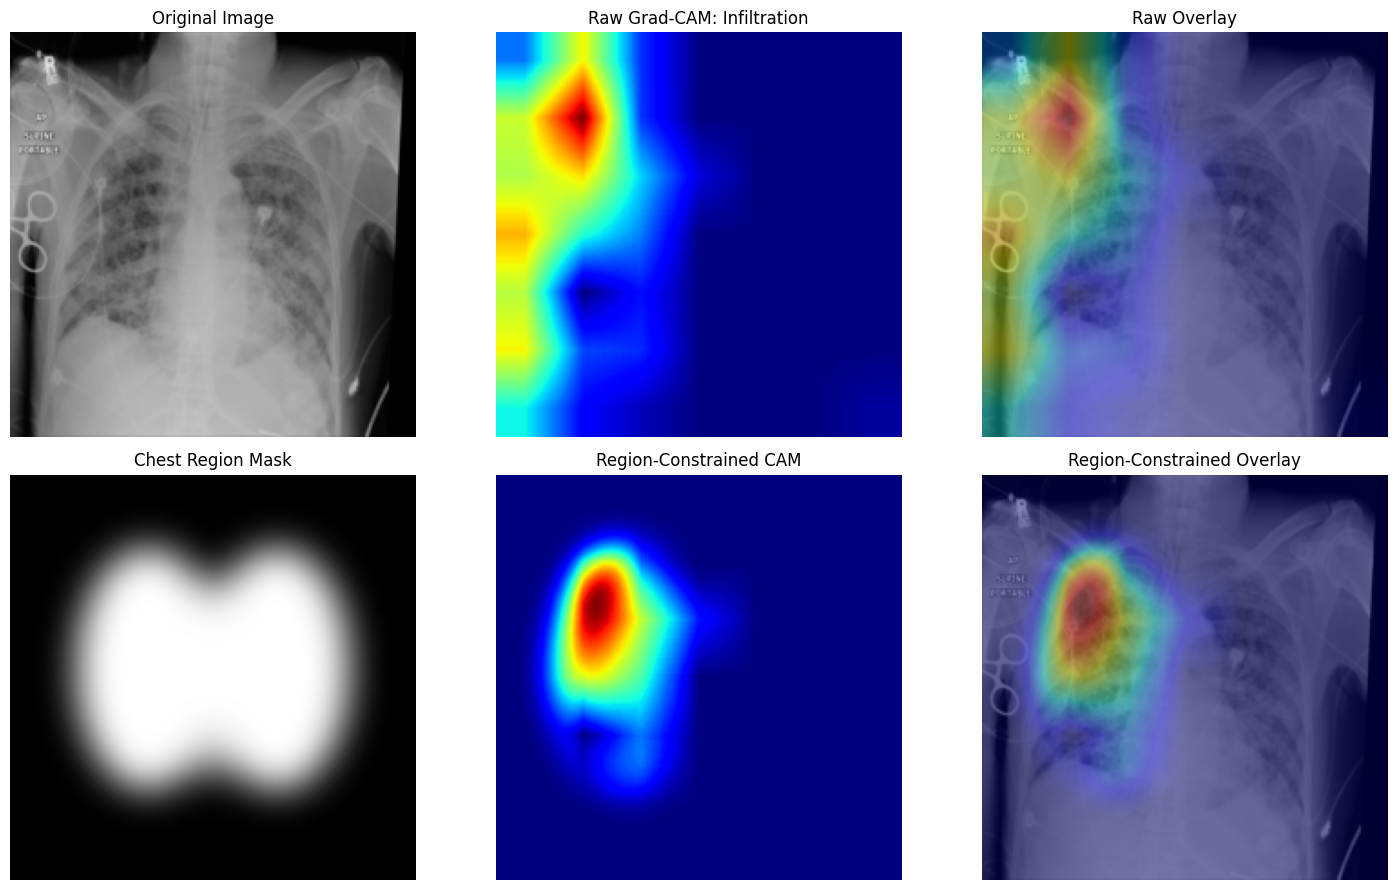

Sample index: 935
True classes: ['Atelectasis', 'Consolidation', 'Infiltration', 'Mass']
Target class: Infiltration
Pred prob (Infiltration): 0.6827


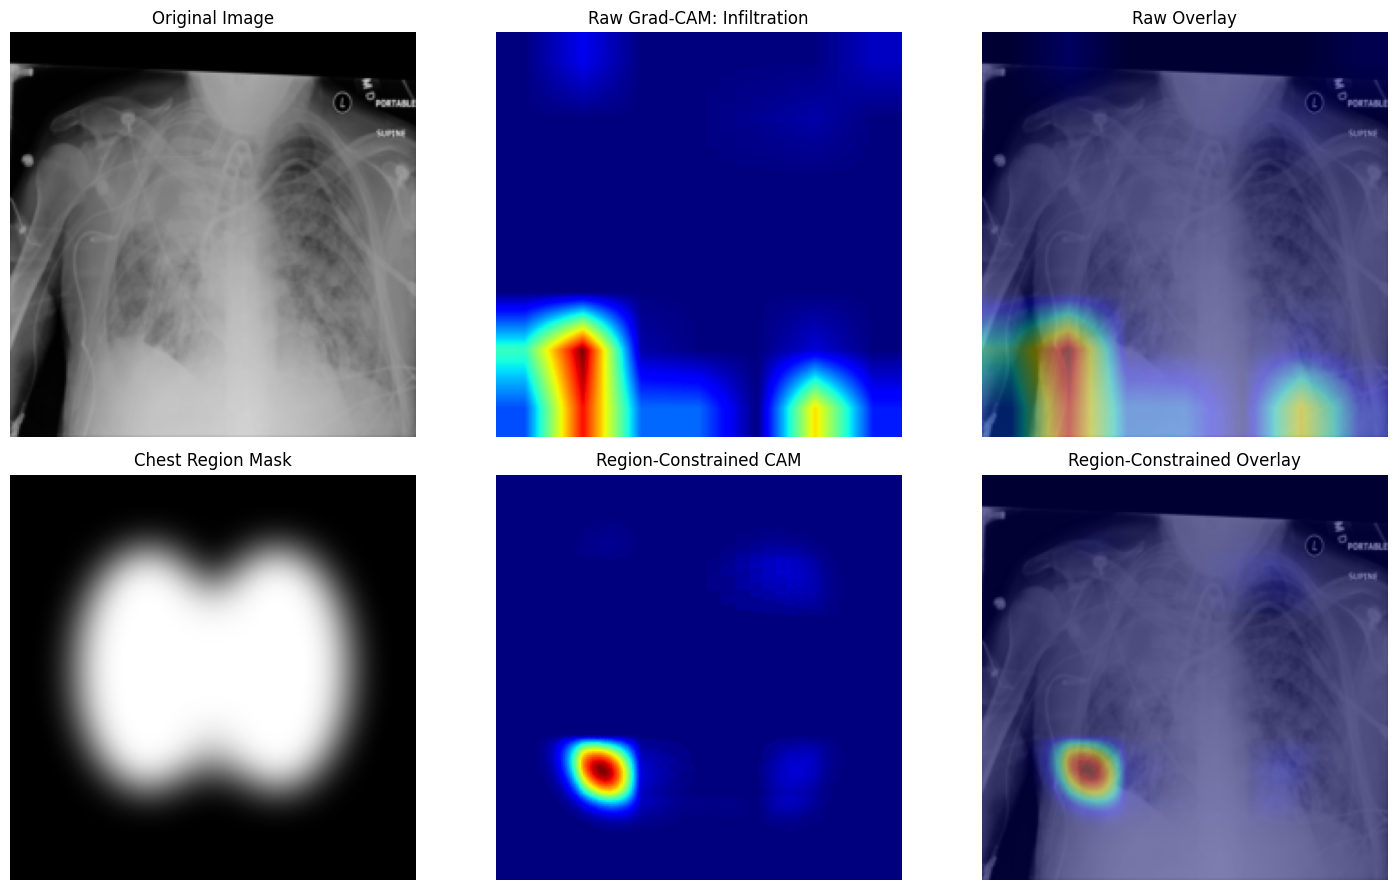

Sample index: 1047
True classes: ['Effusion']
Target class: Effusion
Pred prob (Effusion): 0.9627


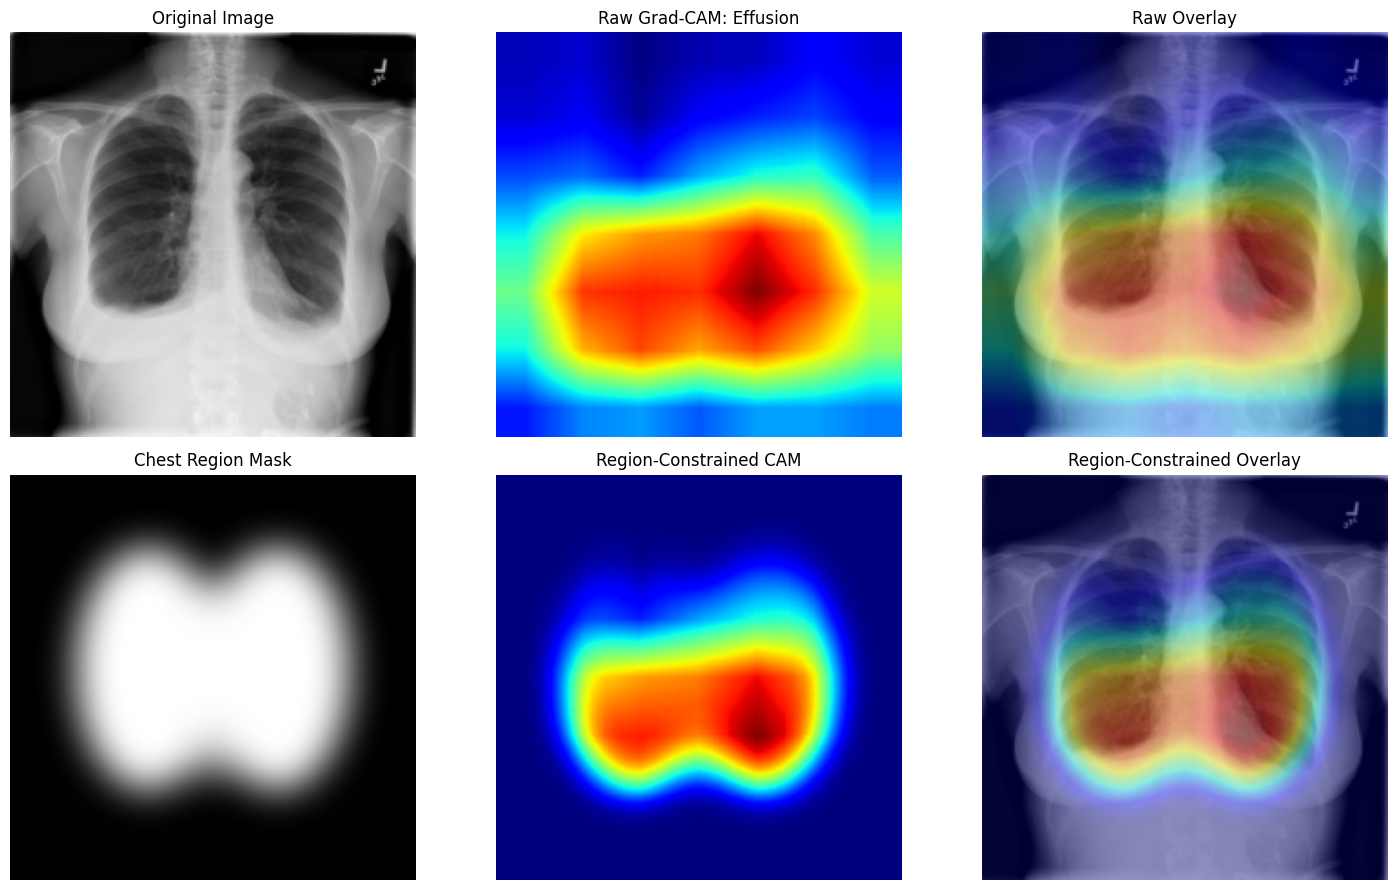

Sample index: 172
True classes: ['Effusion']
Target class: Effusion
Pred prob (Effusion): 0.9573


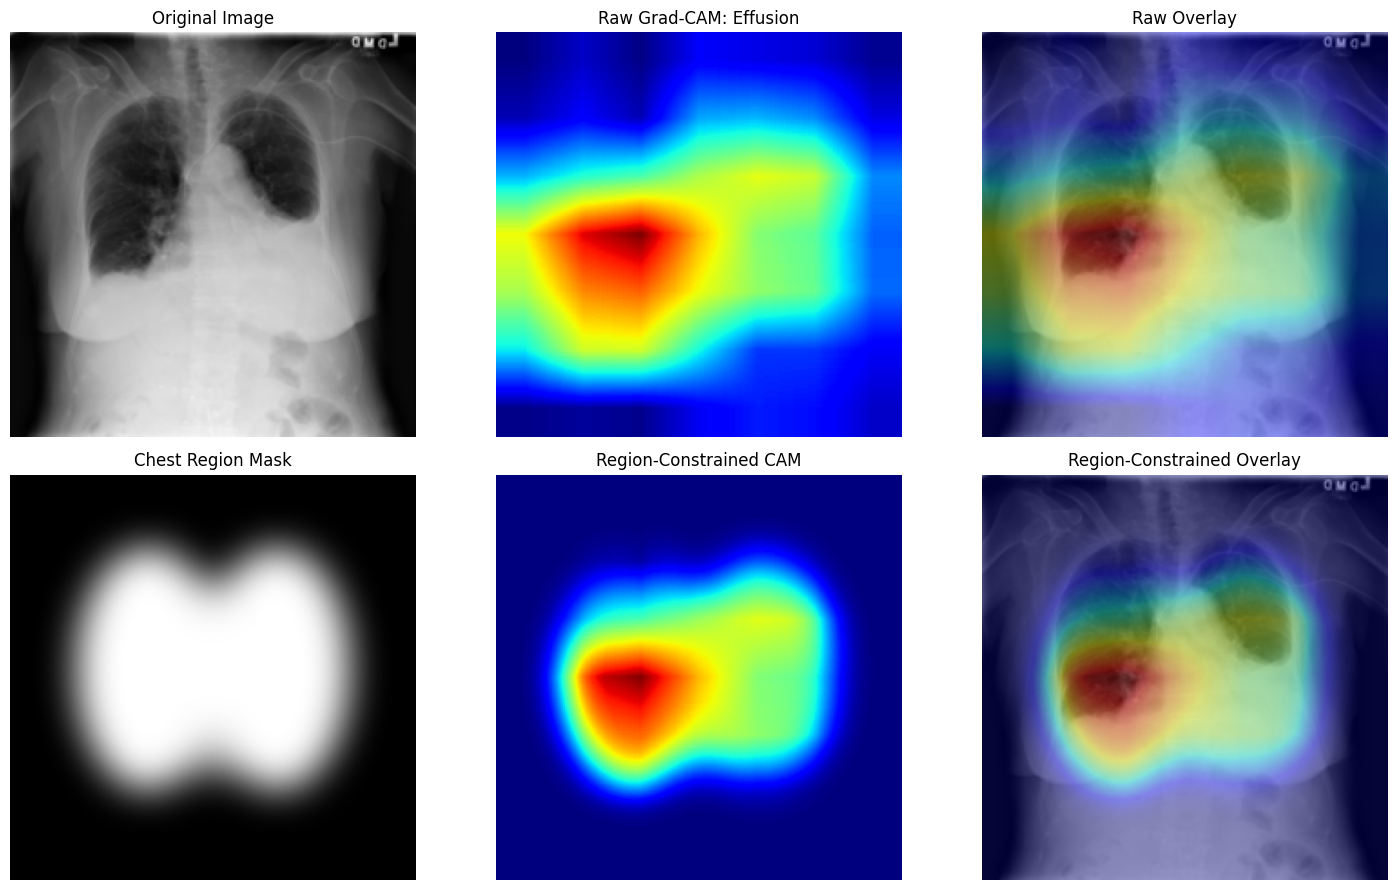

In [22]:
# 本代码块：展示若干典型病例的原始 Grad-CAM 与区域约束后热力图
for case in typical_cases[:5]:
    _ = visualize_case_with_region_constraint(
        model=clean_model,
        dataset=medium_exp["test_dataset"],
        device=device,
        class_names=all_labels,
        sample_idx=case["sample_idx"],
        target_class_idx=case["class_idx"],
        chest_mask=chest_mask
    )


## 7. 做一个简单的“区域约束改进实验”


In [23]:
# 本代码块：计算胸腔内部/边缘响应占比，并汇总区域约束前后的变化
def compute_cam_region_metrics(cam, mask):
    h, w = mask.shape

    if cam.shape != mask.shape:
        cam_img = Image.fromarray(np.uint8(cam * 255))
        cam_img = cam_img.resize((w, h), resample=Image.BILINEAR)
        cam = np.array(cam_img).astype(np.float32) / 255.0

    eps = 1e-8
    total_energy = cam.sum() + eps

    inside_energy = (cam * mask).sum()
    inside_ratio = inside_energy / total_energy

    edge_mask = 1.0 - mask
    edge_energy = (cam * edge_mask).sum()
    edge_ratio = edge_energy / total_energy

    return inside_ratio, edge_ratio


def run_region_constraint_experiment(
    model,
    dataset,
    device,
    class_names,
    case_list,
    chest_mask
):
    records = []
    target_layer = model.features.denseblock4.denselayer16.conv2

    for case in case_list:
        sample_idx = case["sample_idx"]
        class_idx = case["class_idx"]
        class_name = case["class_name"]

        image_tensor, _ = dataset[sample_idx]
        input_tensor = image_tensor.unsqueeze(0).to(device)

        logits = model(input_tensor)
        probs = torch.sigmoid(logits).squeeze(0).detach().cpu().numpy()

        gradcam = GradCAM(model, target_layer)
        cam_raw = gradcam.generate(input_tensor, class_idx)
        gradcam.remove_hooks()

        cam_rc = apply_region_constraint(cam_raw, chest_mask)

        raw_inside, raw_edge = compute_cam_region_metrics(cam_raw, chest_mask)
        rc_inside, rc_edge = compute_cam_region_metrics(cam_rc, chest_mask)

        records.append({
            "sample_idx": sample_idx,
            "class_name": class_name,
            "prob": probs[class_idx],
            "raw_inside_ratio": raw_inside,
            "raw_edge_ratio": raw_edge,
            "rc_inside_ratio": rc_inside,
            "rc_edge_ratio": rc_edge
        })

    return pd.DataFrame(records)


region_exp_df = run_region_constraint_experiment(
    model=clean_model,
    dataset=medium_exp["test_dataset"],
    device=device,
    class_names=all_labels,
    case_list=typical_cases[:9],
    chest_mask=chest_mask
)

summary_df = pd.DataFrame({
    "Metric": [
        "Raw Inside Ratio",
        "Raw Edge Ratio",
        "Region-Constrained Inside Ratio",
        "Region-Constrained Edge Ratio"
    ],
    "Value": [
        region_exp_df["raw_inside_ratio"].mean(),
        region_exp_df["raw_edge_ratio"].mean(),
        region_exp_df["rc_inside_ratio"].mean(),
        region_exp_df["rc_edge_ratio"].mean()
    ]
})

print("平均胸腔内部响应占比（原始）:", region_exp_df["raw_inside_ratio"].mean())
print("平均边缘响应占比（原始）:", region_exp_df["raw_edge_ratio"].mean())
print("平均胸腔内部响应占比（区域约束后）:", region_exp_df["rc_inside_ratio"].mean())
print("平均边缘响应占比（区域约束后）:", region_exp_df["rc_edge_ratio"].mean())

region_exp_df.to_csv("region_constraint_case_experiment.csv", index=False, encoding="utf-8-sig")
summary_df.to_csv("region_constraint_summary.csv", index=False, encoding="utf-8-sig")

region_exp_df, summary_df


平均胸腔内部响应占比（原始）: 0.41298947
平均边缘响应占比（原始）: 0.5870105
平均胸腔内部响应占比（区域约束后）: 0.8046435
平均边缘响应占比（区域约束后）: 0.19535643


(   sample_idx    class_name      prob  raw_inside_ratio  raw_edge_ratio  \
 0         206  Infiltration  0.720699          0.254075        0.745925   
 1        1568  Infiltration  0.713214          0.259976        0.740024   
 2         935  Infiltration  0.682710          0.053011        0.946988   
 3        1047      Effusion  0.962686          0.482585        0.517415   
 4         172      Effusion  0.957311          0.557441        0.442560   
 5         168      Effusion  0.952422          0.435943        0.564057   
 6        1737   Atelectasis  0.771785          0.485469        0.514531   
 7        1088   Atelectasis  0.693665          0.527577        0.472423   
 8         383   Atelectasis  0.690956          0.660828        0.339172   
 
    rc_inside_ratio  rc_edge_ratio  
 0         0.783486       0.216514  
 1         0.784918       0.215082  
 2         0.474906       0.525094  
 3         0.857537       0.142463  
 4         0.872441       0.127559  
 5         0.843

筛选出的复杂多标签病例数: 20
复杂多标签病例信息：


,sample_idx,true_classes,analyzed_classes,analyzed_probs,num_true_labels,num_analyzed_labels
0,7,Effusion|Pneumothorax,Effusion|Pneumothorax,0.4517|0.3695,2,2
1,16,Effusion|Emphysema|Nodule|Pneumothorax,Effusion|Pneumothorax,0.6820|0.2034,4,2
2,22,Atelectasis|Effusion|Emphysema|Infiltration|Pn...,Atelectasis|Effusion|Emphysema|Pneumothorax,0.2682|0.4845|0.2375|0.3328,5,4
3,23,Effusion|Infiltration,Effusion|Infiltration,0.6271|0.4329,2,2
4,26,Effusion|Infiltration|Nodule,Effusion|Infiltration,0.6069|0.5058,3,2


多标签热力图重叠指标：


,sample_idx,class_a,class_b,prob_a,prob_b,raw_iou,region_constrained_iou,iou_change,raw_corr,region_constrained_corr,corr_change,class_a_raw_inside_ratio,class_a_rc_inside_ratio,class_b_raw_inside_ratio,class_b_rc_inside_ratio
0,7,Effusion,Pneumothorax,0.451659,0.369547,0.000000,0.00000,0.000000,-0.197998,0.346605,0.544604,0.528293,0.878623,0.493293,0.875363
1,16,Effusion,Pneumothorax,0.682025,0.203416,0.000000,0.00000,0.000000,-0.160266,0.009786,0.170052,0.383345,0.836187,0.100094,0.648254
2,22,Atelectasis,Effusion,0.268246,0.484492,0.437651,0.50579,0.068139,0.649272,0.860973,0.211701,0.326279,0.822233,0.473747,0.853877
3,22,Atelectasis,Emphysema,0.268246,0.237484,0.000000,0.00000,0.000000,-0.415539,-0.030059,0.385480,0.326279,0.822233,0.497366,0.863763
4,22,Atelectasis,Pneumothorax,0.268246,0.332771,0.000000,0.00000,0.000000,-0.393576,-0.109203,0.284373,0.326279,0.822233,0.444137,0.849256


,Metric,Value
0,Mean Raw IoU,0.140714
1,Mean Region-Constrained IoU,0.136521
2,Mean IoU Change,-0.004193
3,Mean Raw Correlation,0.000183
4,Mean Region-Constrained Correlation,0.291779
5,Mean Correlation Change,0.291596


Saved to: multilabel_case_figures\multilabel_case_7.png


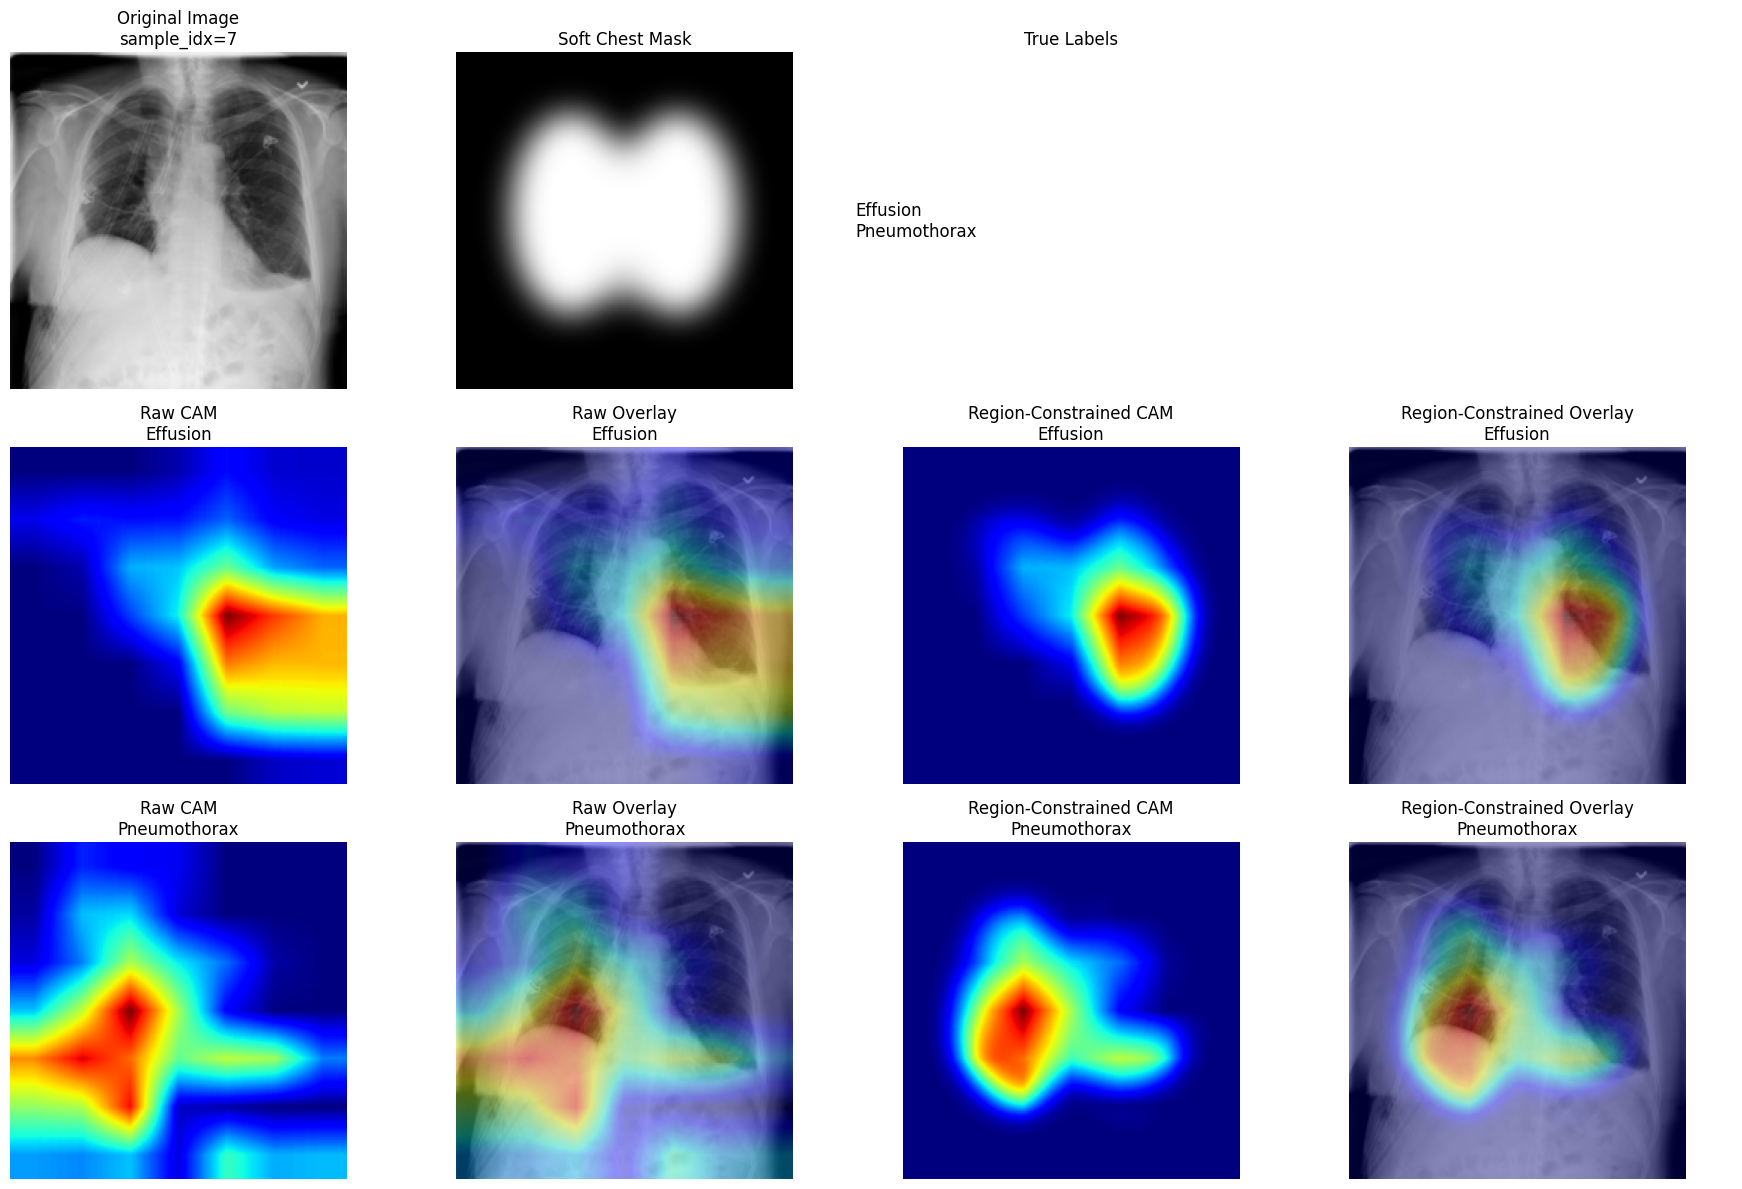

Saved to: multilabel_case_figures\multilabel_case_16.png


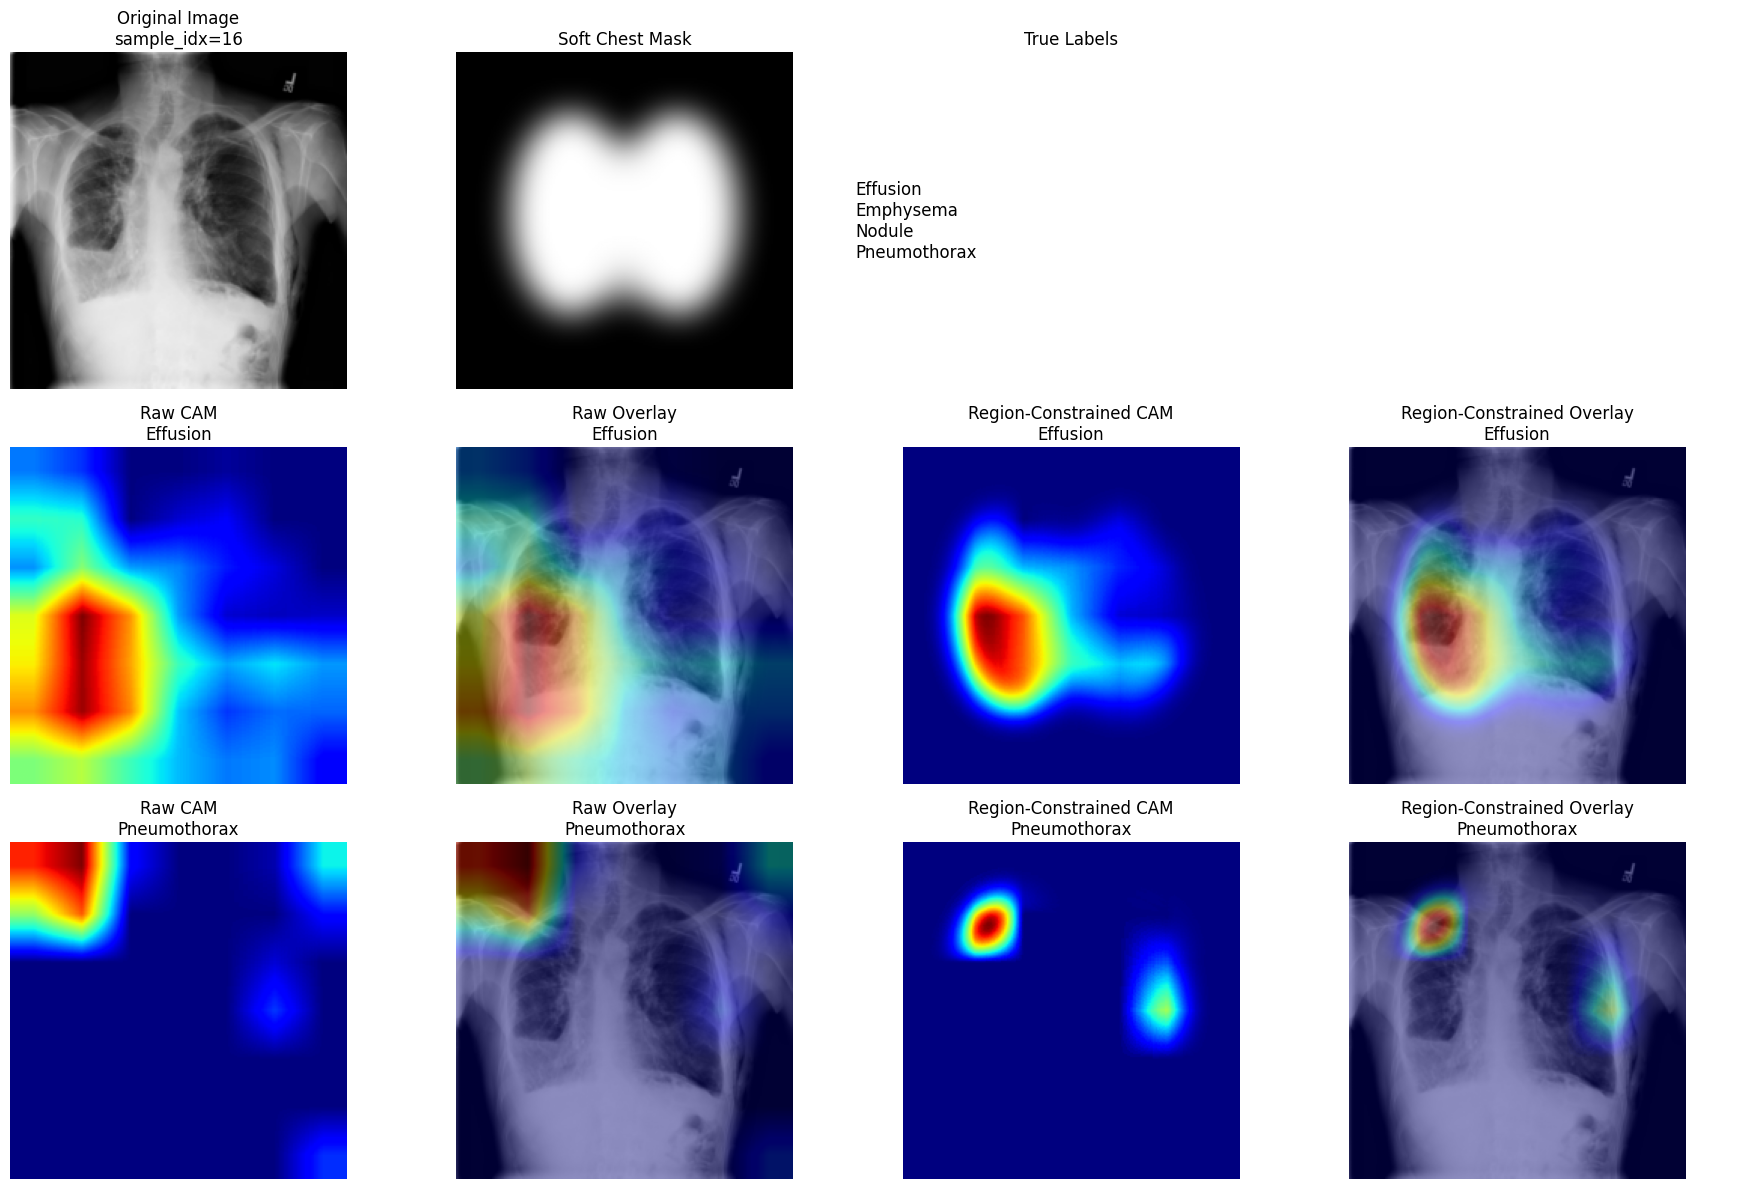

Saved to: multilabel_case_figures\multilabel_case_22.png


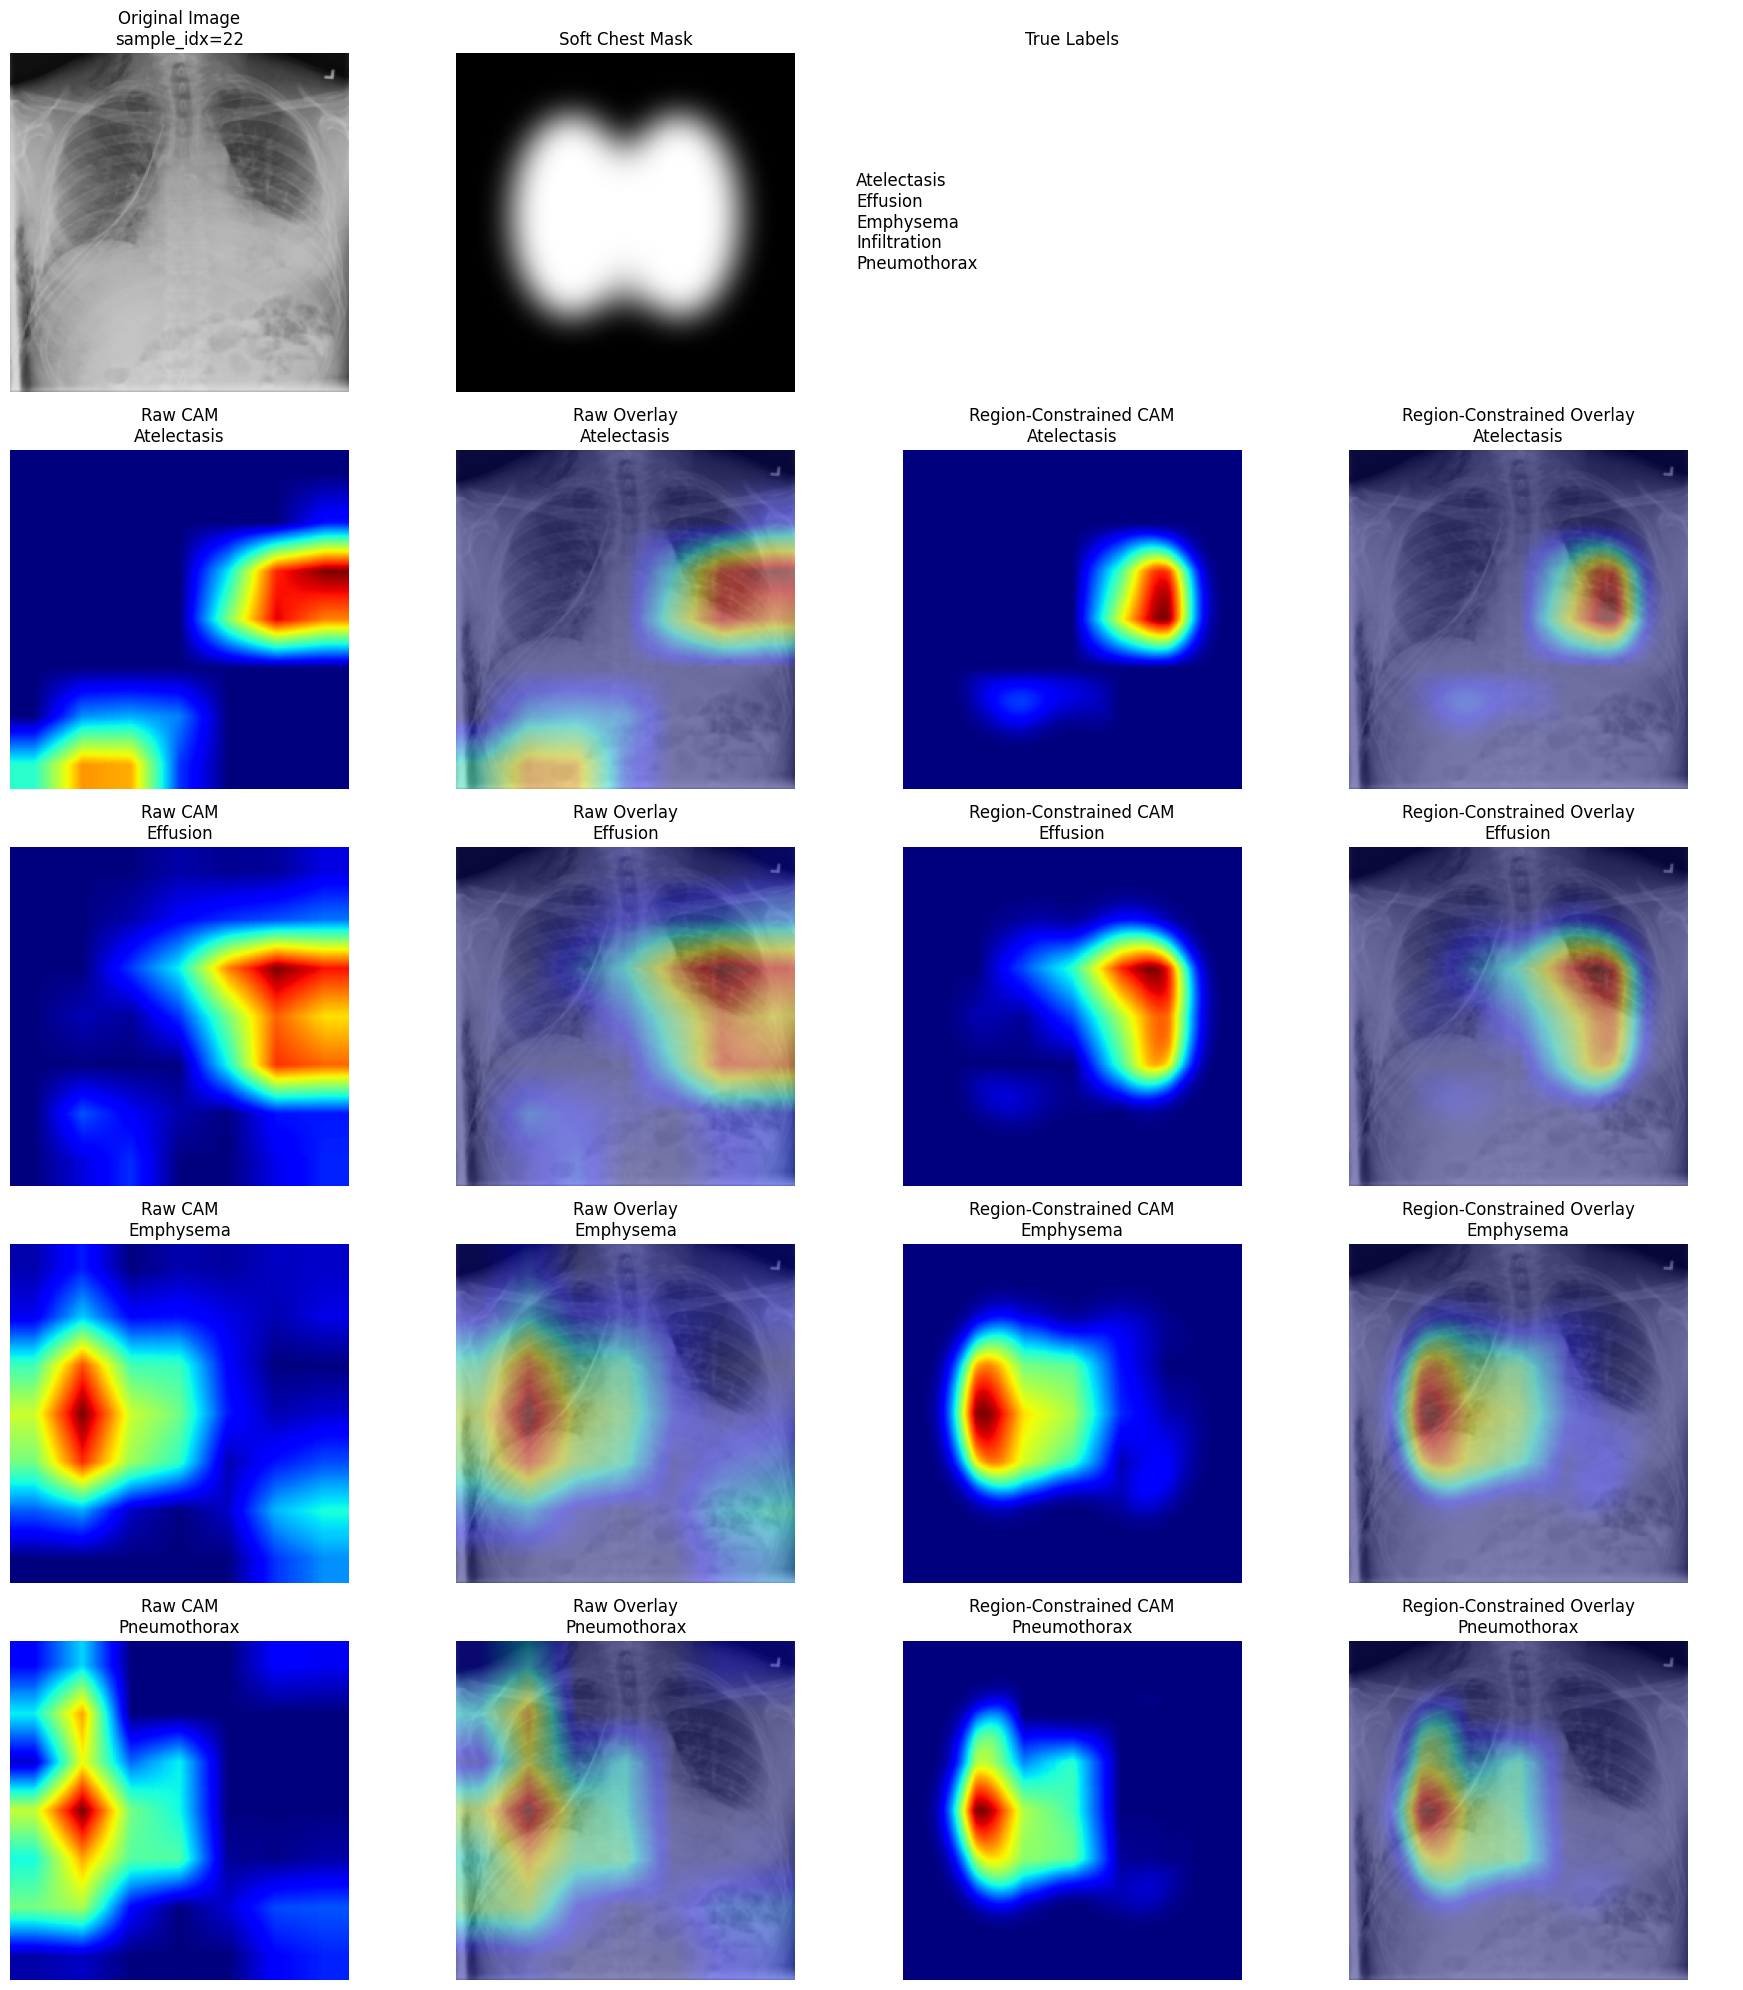

In [24]:
# ============================================================
# 盲审补充实验 2：复杂多标签病例解释分析
# 建议运行位置：Grad-CAM、胸腔区域约束与 compute_cam_region_metrics 定义完成之后
# 主要输出：
# 1. multilabel_cases_info.csv
# 2. multilabel_cam_overlap_metrics.csv
# 3. multilabel_cam_overlap_summary.csv
# 4. multilabel_case_figures/*.png
# ============================================================


def resize_cam_to_mask(cam, mask):
    """将 Grad-CAM 输出 resize 到 mask 尺寸。"""
    h, w = mask.shape

    if cam.shape == mask.shape:
        cam_resized = cam.astype(np.float32)
    else:
        cam_img = Image.fromarray(np.uint8(cam * 255))
        cam_img = cam_img.resize((w, h), resample=Image.BILINEAR)
        cam_resized = np.array(cam_img).astype(np.float32) / 255.0

    cam_resized = cam_resized - cam_resized.min()
    if cam_resized.max() > 0:
        cam_resized = cam_resized / cam_resized.max()

    return cam_resized


def binarize_heatmap(cam, threshold=0.6):
    """将热力图二值化，保留高响应区域。"""
    return cam >= threshold


def heatmap_iou(cam_a, cam_b, threshold=0.6):
    """
    计算两个热力图高响应区域的 IoU。
    IoU 越高，说明两个类别热力图重叠越明显。
    """
    bin_a = binarize_heatmap(cam_a, threshold=threshold)
    bin_b = binarize_heatmap(cam_b, threshold=threshold)

    intersection = np.logical_and(bin_a, bin_b).sum()
    union = np.logical_or(bin_a, bin_b).sum()

    if union == 0:
        return 0.0

    return intersection / union


def heatmap_corr(cam_a, cam_b):
    """
    计算两个热力图的 Pearson 相关系数。
    相关系数越高，说明两个类别响应分布越相似。
    """
    a = cam_a.flatten()
    b = cam_b.flatten()

    if np.std(a) < 1e-8 or np.std(b) < 1e-8:
        return 0.0

    return float(np.corrcoef(a, b)[0, 1])


def find_multilabel_cases(
    all_probs,
    all_labels_np,
    class_names,
    min_true_labels=2,
    min_prob=0.20,
    max_cases=20,
    exclude_no_finding=True
):
    """
    筛选复杂多标签病例。

    筛选标准：
    1. 真实阳性标签数量 >= min_true_labels；
    2. 至少有两个真实阳性标签的预测概率 >= min_prob；
    3. 默认排除 No Finding。
    """
    selected_cases = []

    for sample_idx in range(len(all_labels_np)):
        true_indices = np.where(all_labels_np[sample_idx] == 1)[0].tolist()

        if exclude_no_finding and "No Finding" in class_names:
            no_finding_idx = class_names.index("No Finding")
            true_indices = [i for i in true_indices if i != no_finding_idx]

        if len(true_indices) < min_true_labels:
            continue

        confident_indices = [
            i for i in true_indices
            if all_probs[sample_idx, i] >= min_prob
        ]

        if len(confident_indices) < min_true_labels:
            continue

        selected_cases.append({
            "sample_idx": sample_idx,
            "true_class_indices": true_indices,
            "selected_class_indices": confident_indices,
            "true_classes": [class_names[i] for i in true_indices],
            "selected_classes": [class_names[i] for i in confident_indices],
            "selected_probs": [float(all_probs[sample_idx, i]) for i in confident_indices]
        })

        if len(selected_cases) >= max_cases:
            break

    return selected_cases


def generate_cam_for_one_class(model, image_tensor, device, class_idx):
    """对单张图像、单个类别生成 Grad-CAM。"""
    input_tensor = image_tensor.unsqueeze(0).to(device)
    target_layer = model.features.denseblock4.denselayer16.conv2

    gradcam = GradCAM(model, target_layer)
    cam_raw = gradcam.generate(input_tensor, class_idx)
    gradcam.remove_hooks()

    return cam_raw


def run_multilabel_overlap_experiment(
    model,
    dataset,
    all_probs,
    all_labels_np,
    class_names,
    chest_mask,
    min_true_labels=2,
    min_prob=0.20,
    max_cases=20,
    heatmap_threshold=0.6
):
    """
    对复杂多标签病例进行 Grad-CAM 重叠分析。

    输出：
    1. case_df：病例层面的标签信息；
    2. pair_df：类别对层面的热力图重叠指标。
    """
    multilabel_cases = find_multilabel_cases(
        all_probs=all_probs,
        all_labels_np=all_labels_np,
        class_names=class_names,
        min_true_labels=min_true_labels,
        min_prob=min_prob,
        max_cases=max_cases,
        exclude_no_finding=True
    )

    print("筛选出的复杂多标签病例数:", len(multilabel_cases))

    case_records = []
    pair_records = []

    for case in multilabel_cases:
        sample_idx = case["sample_idx"]
        selected_class_indices = case["selected_class_indices"]

        image_tensor, label_tensor = dataset[sample_idx]

        case_records.append({
            "sample_idx": sample_idx,
            "true_classes": "|".join(case["true_classes"]),
            "analyzed_classes": "|".join(case["selected_classes"]),
            "analyzed_probs": "|".join([f"{p:.4f}" for p in case["selected_probs"]]),
            "num_true_labels": len(case["true_classes"]),
            "num_analyzed_labels": len(case["selected_classes"])
        })

        cam_dict = {}

        for class_idx in selected_class_indices:
            class_name = class_names[class_idx]

            cam_raw = generate_cam_for_one_class(
                model=model,
                image_tensor=image_tensor,
                device=device,
                class_idx=class_idx
            )

            cam_raw_resized = resize_cam_to_mask(cam_raw, chest_mask)
            cam_rc = apply_region_constraint(cam_raw_resized, chest_mask)

            raw_inside, raw_edge = compute_cam_region_metrics(cam_raw_resized, chest_mask)
            rc_inside, rc_edge = compute_cam_region_metrics(cam_rc, chest_mask)

            cam_dict[class_idx] = {
                "class_name": class_name,
                "prob": float(all_probs[sample_idx, class_idx]),
                "cam_raw": cam_raw_resized,
                "cam_rc": cam_rc,
                "raw_inside_ratio": raw_inside,
                "raw_edge_ratio": raw_edge,
                "rc_inside_ratio": rc_inside,
                "rc_edge_ratio": rc_edge
            }

        # 对同一样本中的不同标签两两计算热力图重叠程度
        for i in range(len(selected_class_indices)):
            for j in range(i + 1, len(selected_class_indices)):
                class_idx_a = selected_class_indices[i]
                class_idx_b = selected_class_indices[j]

                item_a = cam_dict[class_idx_a]
                item_b = cam_dict[class_idx_b]

                raw_iou = heatmap_iou(item_a["cam_raw"], item_b["cam_raw"], threshold=heatmap_threshold)
                rc_iou = heatmap_iou(item_a["cam_rc"], item_b["cam_rc"], threshold=heatmap_threshold)
                raw_corr = heatmap_corr(item_a["cam_raw"], item_b["cam_raw"])
                rc_corr = heatmap_corr(item_a["cam_rc"], item_b["cam_rc"])

                pair_records.append({
                    "sample_idx": sample_idx,
                    "class_a": item_a["class_name"],
                    "class_b": item_b["class_name"],
                    "prob_a": item_a["prob"],
                    "prob_b": item_b["prob"],
                    "raw_iou": raw_iou,
                    "region_constrained_iou": rc_iou,
                    "iou_change": rc_iou - raw_iou,
                    "raw_corr": raw_corr,
                    "region_constrained_corr": rc_corr,
                    "corr_change": rc_corr - raw_corr,
                    "class_a_raw_inside_ratio": item_a["raw_inside_ratio"],
                    "class_a_rc_inside_ratio": item_a["rc_inside_ratio"],
                    "class_b_raw_inside_ratio": item_b["raw_inside_ratio"],
                    "class_b_rc_inside_ratio": item_b["rc_inside_ratio"]
                })

    case_df = pd.DataFrame(case_records)
    pair_df = pd.DataFrame(pair_records)

    return case_df, pair_df


# 说明：此处默认使用 medium baseline 的 clean_model 和 medium_exp。
# 如果你希望使用类别重加权模型解释，可将 model=clean_model 改为 model=medium_weighted_threshold_exp["model"]，
# 并把 dataset / all_probs / all_labels_np 改成 medium_weighted_threshold_exp 对应对象。
multilabel_case_df, multilabel_pair_df = run_multilabel_overlap_experiment(
    model=clean_model,
    dataset=medium_exp["test_dataset"],
    all_probs=medium_exp["all_probs"],
    all_labels_np=medium_exp["all_labels_np"],
    class_names=all_labels,
    chest_mask=chest_mask,
    min_true_labels=2,
    min_prob=0.20,
    max_cases=20,
    heatmap_threshold=0.6
)

multilabel_case_df.to_csv("multilabel_cases_info.csv", index=False, encoding="utf-8-sig")
multilabel_pair_df.to_csv("multilabel_cam_overlap_metrics.csv", index=False, encoding="utf-8-sig")

print("复杂多标签病例信息：")
display(multilabel_case_df.head())

print("多标签热力图重叠指标：")
display(multilabel_pair_df.head())


# 汇总多标签热力图重叠程度
multilabel_summary_df = pd.DataFrame({
    "Metric": [
        "Mean Raw IoU",
        "Mean Region-Constrained IoU",
        "Mean IoU Change",
        "Mean Raw Correlation",
        "Mean Region-Constrained Correlation",
        "Mean Correlation Change"
    ],
    "Value": [
        multilabel_pair_df["raw_iou"].mean() if len(multilabel_pair_df) > 0 else np.nan,
        multilabel_pair_df["region_constrained_iou"].mean() if len(multilabel_pair_df) > 0 else np.nan,
        multilabel_pair_df["iou_change"].mean() if len(multilabel_pair_df) > 0 else np.nan,
        multilabel_pair_df["raw_corr"].mean() if len(multilabel_pair_df) > 0 else np.nan,
        multilabel_pair_df["region_constrained_corr"].mean() if len(multilabel_pair_df) > 0 else np.nan,
        multilabel_pair_df["corr_change"].mean() if len(multilabel_pair_df) > 0 else np.nan
    ]
})

multilabel_summary_df.to_csv("multilabel_cam_overlap_summary.csv", index=False, encoding="utf-8-sig")
display(multilabel_summary_df)


def visualize_multilabel_case(
    model,
    dataset,
    sample_idx,
    class_indices,
    class_names,
    chest_mask,
    save_dir="multilabel_case_figures",
    file_prefix="multilabel_case"
):
    """
    可视化一个复杂多标签病例中多个类别的 Grad-CAM。

    图像布局：
    第 1 行：原图 + mask + 真实标签；
    后续每一行：某个类别的 Raw CAM、Raw Overlay、Region-Constrained CAM、Region-Constrained Overlay。
    """
    os.makedirs(save_dir, exist_ok=True)

    image_tensor, label_tensor = dataset[sample_idx]
    img = denormalize_image(image_tensor)

    true_indices = np.where(label_tensor.numpy() == 1)[0].tolist()
    true_classes = [class_names[i] for i in true_indices]

    n_classes = len(class_indices)
    fig, axes = plt.subplots(n_classes + 1, 4, figsize=(18, 4 * (n_classes + 1)))

    axes[0, 0].imshow(img)
    axes[0, 0].set_title(f"Original Image\nsample_idx={sample_idx}")
    axes[0, 0].axis("off")

    axes[0, 1].imshow(chest_mask, cmap="gray")
    axes[0, 1].set_title("Soft Chest Mask")
    axes[0, 1].axis("off")

    axes[0, 2].axis("off")
    axes[0, 2].set_title("True Labels")
    axes[0, 2].text(0.0, 0.5, "\n".join(true_classes), fontsize=12, va="center")

    axes[0, 3].axis("off")

    for row_idx, class_idx in enumerate(class_indices, start=1):
        class_name = class_names[class_idx]

        cam_raw = generate_cam_for_one_class(
            model=model,
            image_tensor=image_tensor,
            device=device,
            class_idx=class_idx
        )

        cam_raw_resized = resize_cam_to_mask(cam_raw, chest_mask)
        cam_rc = apply_region_constraint(cam_raw_resized, chest_mask)

        _, _, overlay_raw = show_cam_on_image(img, cam_raw_resized)
        _, _, overlay_rc = show_cam_on_image(img, cam_rc)

        axes[row_idx, 0].imshow(cam_raw_resized, cmap="jet")
        axes[row_idx, 0].set_title(f"Raw CAM\n{class_name}")
        axes[row_idx, 0].axis("off")

        axes[row_idx, 1].imshow(overlay_raw)
        axes[row_idx, 1].set_title(f"Raw Overlay\n{class_name}")
        axes[row_idx, 1].axis("off")

        axes[row_idx, 2].imshow(cam_rc, cmap="jet")
        axes[row_idx, 2].set_title(f"Region-Constrained CAM\n{class_name}")
        axes[row_idx, 2].axis("off")

        axes[row_idx, 3].imshow(overlay_rc)
        axes[row_idx, 3].set_title(f"Region-Constrained Overlay\n{class_name}")
        axes[row_idx, 3].axis("off")

    plt.tight_layout()

    save_path = os.path.join(save_dir, f"{file_prefix}_{sample_idx}.png")
    fig.savefig(save_path, dpi=300, bbox_inches="tight")
    print("Saved to:", save_path)

    plt.show()

    return fig


# 选取前 3 个复杂多标签病例进行可视化，作为论文图例候选
if len(multilabel_case_df) > 0:
    for _, row in multilabel_case_df.head(3).iterrows():
        sample_idx = int(row["sample_idx"])
        analyzed_classes = row["analyzed_classes"].split("|")
        class_indices = [all_labels.index(c) for c in analyzed_classes]

        _ = visualize_multilabel_case(
            model=clean_model,
            dataset=medium_exp["test_dataset"],
            sample_idx=sample_idx,
            class_indices=class_indices,
            class_names=all_labels,
            chest_mask=chest_mask,
            save_dir="multilabel_case_figures",
            file_prefix="multilabel_case"
        )
else:
    print("未筛选到满足条件的复杂多标签病例，可降低 min_prob 或增加 max_cases 后重试。")
